# **Phân tích cấu trúc thị trường chứng khoán Việt Nam bằng PCA từ rổ VN30**

---



In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **1. Thu thập và xử lý dữ liệu**

In [25]:
import datetime
import pandas as pd

# Define the end date as yesterday to ensure full day's data and avoid future date issues
end_date = datetime.date.today() - datetime.timedelta(days=1)
start_date = end_date - datetime.timedelta(days=365) # One year prior to yesterday

# List of VN30 stock tickers (adjust if specific tickers are needed)
# Using '.VN' suffix for consistency with Yahoo Finance for Vietnamese stocks.
vn30_tickers = [
    "ACB.VN", "BID.VN", "BVH.VN", "CTG.VN", "FPT.VN",
    "GAS.VN", "GVR.VN", "HDB.VN", "HPG.VN", "KDH.VN",
    "MBB.VN", "MSN.VN", "MWG.VN", "NLG.VN", "NVL.VN",
    "PDR.VN", "PLX.VN", "POW.VN", "SBT.VN", "SSB.VN",
    "SSI.VN", "STB.VN", "TCB.VN", "TPB.VN", "VCB.VN",
    "VHM.VN", "VIB.VN", "VIC.VN", "VJC.VN", "VNM.VN"
]

# VN30-Index ticker - using ^VNINDEX as a more reliable proxy if ^VNI has issues
vn30_index_ticker = "^VNINDEX"

# Download data for VN30 stocks
print(f"Downloading data for VN30 stocks from {start_date} to {end_date}...")
stock_data = yf.download(vn30_tickers, start=start_date, end=end_date)

# Extract only the 'Close' price for each stock
close_prices = stock_data['Close']

# Download data for VN30-Index
print(f"Downloading data for VN30-Index from {start_date} to {end_date}...")
vn30_index_data = yf.download(vn30_index_ticker, start=start_date, end=end_date)

# Extract the 'Close' price for VN30-Index and rename the column
vn30_index_close = vn30_index_data['Close'].rename('VN30_Index_Close')

# Merge stock closing prices with VN30-Index closing prices
merged_data = pd.merge(close_prices, vn30_index_close, left_index=True, right_index=True, how='outer')

# Display the first few rows of the collected data
print("\nCollected and merged data (first 5 rows):")
display(merged_data.head())

# Display basic information about the dataframe
print("\nData Info:")
merged_data.info()

# Check for any missing values
print("\nMissing values per column:")
print(merged_data.isnull().sum()[merged_data.isnull().sum() > 0])

# Handle missing values: forward fill then backward fill
merged_data_filled = merged_data.ffill().bfill()
print("\nData after forward/backward fill (first 5 rows):")
display(merged_data_filled.head())

# Display basic information after filling missing values
print("\nData Info after filling missing values:")
merged_data_filled.info()

# Describe the data to see basic statistics
print("\nDescriptive Statistics:")
display(merged_data_filled.describe())

/tmp/ipykernel_8246/2046765873.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(vn30_tickers, start=start_date, end=end_date)
[***                    7%                       ]  2 of 30 completed

[*********************100%***********************]  30 of 30 completed
/tmp/ipykernel_8246/2046765873.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vn30_index_data = yf.download(vn30_index_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^VNINDEX']: YFTzMissingError('possibly delisted; no timezone found')



Collected and merged data (first 5 rows):


Ticker,ACB.VN,BID.VN,BVH.VN,CTG.VN,FPT.VN,GAS.VN,GVR.VN,HDB.VN,HPG.VN,KDH.VN,...,STB.VN,TCB.VN,TPB.VN,VCB.VN,VHM.VN,VIB.VN,VIC.VN,VJC.VN,VNM.VN,^VNINDEX
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-06,19930.230469,34565.464844,46605.046875,25693.433594,93488.031250,56047.531250,23958.347656,16385.226562,21208.333984,24636.363281,...,38850.0,26157.097656,12207.264648,56586.957031,60900.0,14554.578125,35250.0,89000.0,52492.105469,NaN
2025-05-07,19930.230469,34516.015625,48076.785156,25590.931641,93488.031250,56893.886719,24500.615234,16153.905273,21166.666016,26000.000000,...,38850.0,26303.226562,12295.722656,56586.957031,62000.0,14512.993164,36700.0,88900.0,52768.871094,NaN
2025-05-08,20054.794922,35059.964844,47978.671875,25659.265625,97408.226562,57740.242188,26176.712891,16385.226562,21416.666016,26181.818359,...,39500.0,26692.904297,12428.410156,56686.230469,62200.0,14637.747070,39250.0,89800.0,52953.375000,NaN
2025-05-09,20054.794922,34713.816406,47291.859375,25590.931641,98856.992188,57458.121094,26275.306641,16346.672852,21375.000000,25863.636719,...,39750.0,26887.742188,12428.410156,56189.855469,62200.0,14596.163086,38250.0,89500.0,53230.136719,NaN
2025-05-12,20262.400391,34862.164062,47880.554688,25864.265625,100817.085938,58586.597656,27557.029297,16577.994141,21166.666016,25727.273438,...,40000.0,28641.291016,13047.619141,56189.855469,62300.0,14970.422852,39700.0,90400.0,54060.414062,NaN



Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 249 entries, 2025-05-06 to 2026-05-05
Data columns (total 31 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ACB.VN    249 non-null    float64
 1   BID.VN    249 non-null    float64
 2   BVH.VN    249 non-null    float64
 3   CTG.VN    249 non-null    float64
 4   FPT.VN    249 non-null    float64
 5   GAS.VN    249 non-null    float64
 6   GVR.VN    249 non-null    float64
 7   HDB.VN    249 non-null    float64
 8   HPG.VN    249 non-null    float64
 9   KDH.VN    249 non-null    float64
 10  MBB.VN    249 non-null    float64
 11  MSN.VN    249 non-null    float64
 12  MWG.VN    249 non-null    float64
 13  NLG.VN    249 non-null    float64
 14  NVL.VN    249 non-null    float64
 15  PDR.VN    249 non-null    float64
 16  PLX.VN    249 non-null    float64
 17  POW.VN    249 non-null    float64
 18  SBT.VN    249 non-null    float64
 19  SSB.VN    249 non-null    float64
 20  S

Ticker,ACB.VN,BID.VN,BVH.VN,CTG.VN,FPT.VN,GAS.VN,GVR.VN,HDB.VN,HPG.VN,KDH.VN,...,STB.VN,TCB.VN,TPB.VN,VCB.VN,VHM.VN,VIB.VN,VIC.VN,VJC.VN,VNM.VN,^VNINDEX
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-06,19930.230469,34565.464844,46605.046875,25693.433594,93488.031250,56047.531250,23958.347656,16385.226562,21208.333984,24636.363281,...,38850.0,26157.097656,12207.264648,56586.957031,60900.0,14554.578125,35250.0,89000.0,52492.105469,NaN
2025-05-07,19930.230469,34516.015625,48076.785156,25590.931641,93488.031250,56893.886719,24500.615234,16153.905273,21166.666016,26000.000000,...,38850.0,26303.226562,12295.722656,56586.957031,62000.0,14512.993164,36700.0,88900.0,52768.871094,NaN
2025-05-08,20054.794922,35059.964844,47978.671875,25659.265625,97408.226562,57740.242188,26176.712891,16385.226562,21416.666016,26181.818359,...,39500.0,26692.904297,12428.410156,56686.230469,62200.0,14637.747070,39250.0,89800.0,52953.375000,NaN
2025-05-09,20054.794922,34713.816406,47291.859375,25590.931641,98856.992188,57458.121094,26275.306641,16346.672852,21375.000000,25863.636719,...,39750.0,26887.742188,12428.410156,56189.855469,62200.0,14596.163086,38250.0,89500.0,53230.136719,NaN
2025-05-12,20262.400391,34862.164062,47880.554688,25864.265625,100817.085938,58586.597656,27557.029297,16577.994141,21166.666016,25727.273438,...,40000.0,28641.291016,13047.619141,56189.855469,62300.0,14970.422852,39700.0,90400.0,54060.414062,NaN



Data Info after filling missing values:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 249 entries, 2025-05-06 to 2026-05-05
Data columns (total 31 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ACB.VN    249 non-null    float64
 1   BID.VN    249 non-null    float64
 2   BVH.VN    249 non-null    float64
 3   CTG.VN    249 non-null    float64
 4   FPT.VN    249 non-null    float64
 5   GAS.VN    249 non-null    float64
 6   GVR.VN    249 non-null    float64
 7   HDB.VN    249 non-null    float64
 8   HPG.VN    249 non-null    float64
 9   KDH.VN    249 non-null    float64
 10  MBB.VN    249 non-null    float64
 11  MSN.VN    249 non-null    float64
 12  MWG.VN    249 non-null    float64
 13  NLG.VN    249 non-null    float64
 14  NVL.VN    249 non-null    float64
 15  PDR.VN    249 non-null    float64
 16  PLX.VN    249 non-null    float64
 17  POW.VN    249 non-null    float64
 18  SBT.VN    249 non-null    float64
 19  SSB.VN    2

Ticker,ACB.VN,BID.VN,BVH.VN,CTG.VN,FPT.VN,GAS.VN,GVR.VN,HDB.VN,HPG.VN,KDH.VN,...,STB.VN,TCB.VN,TPB.VN,VCB.VN,VHM.VN,VIB.VN,VIC.VN,VJC.VN,VNM.VN,^VNINDEX
count,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,...,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,0.0
mean,23923.400853,40132.534011,59806.251992,33564.227457,95613.790569,72909.056115,30466.178174,23483.184990,26267.402932,29863.618113,...,54320.080321,34148.624537,16329.557464,60977.591491,100246.184739,17068.609465,105073.092369,149351.405622,60065.234642,NaN
std,1824.237367,4620.951541,11341.002744,3719.020794,9808.833216,17639.210246,4214.092932,3833.981448,2279.318545,3655.450264,...,7738.696126,3091.144870,2088.373138,4262.300193,19681.868895,1659.083697,49118.173814,39121.985713,4769.184981,NaN
min,19930.230469,34516.015625,46212.585938,25590.931641,73100.000000,56000.000000,23958.347656,16153.905273,21166.666016,23950.000000,...,38850.000000,26157.097656,12207.264648,55296.375000,58000.000000,14512.993164,35250.000000,87000.000000,52153.300781,NaN
25%,23000.000000,37350.000000,51412.726562,31228.453125,93488.031250,61600.000000,27606.326172,21512.837891,25950.000000,26636.363281,...,48500.000000,32050.000000,15100.000000,57778.261719,92000.000000,15928.530273,57800.000000,121500.000000,57311.320312,NaN
50%,23950.000000,39065.406250,54944.898438,34371.800781,98673.226562,64040.890625,29085.236328,24481.455078,26750.000000,28500.000000,...,54800.000000,34250.000000,16900.000000,59900.000000,100000.000000,16687.031250,103250.000000,156400.000000,60081.367188,NaN
75%,25000.000000,40746.699219,70800.000000,35300.000000,101724.085938,79200.000000,32200.000000,25950.000000,27700.000000,33500.000000,...,60800.000000,36400.000000,17600.000000,63000.000000,108000.000000,17777.376953,146000.000000,179900.000000,62100.000000,NaN
max,29450.000000,55000.000000,86000.000000,41500.000000,110945.515625,128700.000000,45750.000000,29700.000000,30350.000000,37000.000000,...,68100.000000,41300.000000,21000.000000,76000.000000,151200.000000,22375.792969,225500.000000,219100.000000,73400.000000,NaN


In [46]:
# Calculate daily returns for all stocks and the index
daily_returns = merged_data_filled.pct_change(fill_method=None)

# Display the first few rows of daily returns
print("\nDaily Returns (first 5 rows):")
display(daily_returns.head())

# Display descriptive statistics of daily returns
print("\nDescriptive Statistics of Daily Returns:")
display(daily_returns.describe())

# Check for any remaining missing values in daily returns (first row will be NaN by definition)
print("\nMissing values in Daily Returns (excluding the first row):")
print(daily_returns.iloc[1:].isnull().sum()[daily_returns.iloc[1:].isnull().sum() > 0])

# Inform about the VN30 Index data status if it's still missing
if '^VNINDEX' in daily_returns.columns and daily_returns['^VNINDEX'].isnull().all():
    print("\nNote: Daily returns for '^VNINDEX' are all NaN, which might indicate a problem with index data download. It will be dropped in the next step.")

# Drop the '^VNINDEX' column if it contains all NaN values or is problematic
daily_returns_cleaned = daily_returns.drop(columns=['^VNINDEX'], errors='ignore')

# Drop any rows with NaN values (primarily the first row from pct_change)
daily_returns_cleaned = daily_returns_cleaned.dropna()

print("\nShape of daily_returns_cleaned:", daily_returns_cleaned.shape)

# Standardize data
mean_returns = daily_returns_cleaned.mean()
standardized_returns = daily_returns_cleaned - mean_returns


Daily Returns (first 5 rows):


Ticker,ACB.VN,BID.VN,BVH.VN,CTG.VN,FPT.VN,GAS.VN,GVR.VN,HDB.VN,HPG.VN,KDH.VN,...,STB.VN,TCB.VN,TPB.VN,VCB.VN,VHM.VN,VIB.VN,VIC.VN,VJC.VN,VNM.VN,^VNINDEX
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-07,0.000000,-0.001431,0.031579,-0.003989,0.000000,0.015101,0.022634,-0.014118,-0.001965,0.055351,...,0.000000,0.005587,0.007246,0.000000,0.018062,-0.002857,0.041135,-0.001124,0.005273,NaN
2025-05-08,0.006250,0.015759,-0.002041,0.002670,0.041933,0.014876,0.068410,0.014320,0.011811,0.006993,...,0.016731,0.014815,0.010791,0.001754,0.003226,0.008596,0.069482,0.010124,0.003496,NaN
2025-05-09,0.000000,-0.009873,-0.014315,-0.002663,0.014873,-0.004886,0.003766,-0.002353,-0.001945,-0.012153,...,0.006329,0.007299,0.000000,-0.008757,0.000000,-0.002841,-0.025478,-0.003341,0.005227,NaN
2025-05-12,0.010352,0.004273,0.012448,0.010681,0.019828,0.019640,0.048781,0.014151,-0.009747,-0.005272,...,0.006289,0.065217,0.049822,0.000000,0.001608,0.025641,0.037908,0.010056,0.015598,NaN



Descriptive Statistics of Daily Returns:


Ticker,ACB.VN,BID.VN,BVH.VN,CTG.VN,FPT.VN,GAS.VN,GVR.VN,HDB.VN,HPG.VN,KDH.VN,...,STB.VN,TCB.VN,TPB.VN,VCB.VN,VHM.VN,VIB.VN,VIC.VN,VJC.VN,VNM.VN,^VNINDEX
count,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,...,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,0.0
mean,0.000635,0.000856,0.001941,0.001448,-0.000728,0.001674,0.001994,0.002176,0.001184,0.000252,...,0.002465,0.001187,0.001395,0.000385,0.004254,0.000528,0.007990,0.003238,0.000783,NaN
std,0.016068,0.020630,0.026477,0.018302,0.019989,0.026804,0.029844,0.022503,0.018287,0.024168,...,0.024150,0.020665,0.022015,0.017741,0.034168,0.017867,0.034435,0.027511,0.018530,NaN
min,-0.068670,-0.069725,-0.069191,-0.068724,-0.069853,-0.069990,-0.069954,-0.069498,-0.069725,-0.069322,...,-0.069492,-0.069952,-0.069909,-0.069805,-0.070000,-0.069915,-0.070000,-0.068504,-0.068910,NaN
25%,-0.006148,-0.007958,-0.014379,-0.007805,-0.013476,-0.010191,-0.015052,-0.009002,-0.008711,-0.012935,...,-0.010333,-0.010445,-0.011321,-0.008368,-0.015177,-0.008914,-0.010292,-0.013469,-0.009082,NaN
50%,0.000000,-0.000515,0.000000,0.001153,-0.002343,0.000000,0.001503,0.001526,0.000000,0.000000,...,0.001779,0.001358,0.000000,0.000000,0.001937,0.000000,0.003718,0.000000,0.000000,NaN
75%,0.007968,0.010181,0.012657,0.010565,0.010159,0.013061,0.019632,0.012550,0.010558,0.010330,...,0.012617,0.011111,0.011453,0.006413,0.020310,0.008559,0.031775,0.013719,0.009577,NaN
max,0.069388,0.069686,0.069808,0.066754,0.069036,0.069882,0.070000,0.070000,0.069034,0.068966,...,0.069692,0.069686,0.068681,0.069659,0.070000,0.068493,0.070000,0.069872,0.069510,NaN



Missing values in Daily Returns (excluding the first row):
Ticker
^VNINDEX    248
dtype: int64

Note: Daily returns for '^VNINDEX' are all NaN, which might indicate a problem with index data download. It will be dropped in the next step.

Shape of daily_returns_cleaned: (248, 30)


## **3. Phân tích dữ liệu thăm dò (Exploratory Data Analysis - EDA)**

### **3.1. Phân phối lợi suất hàng ngày**

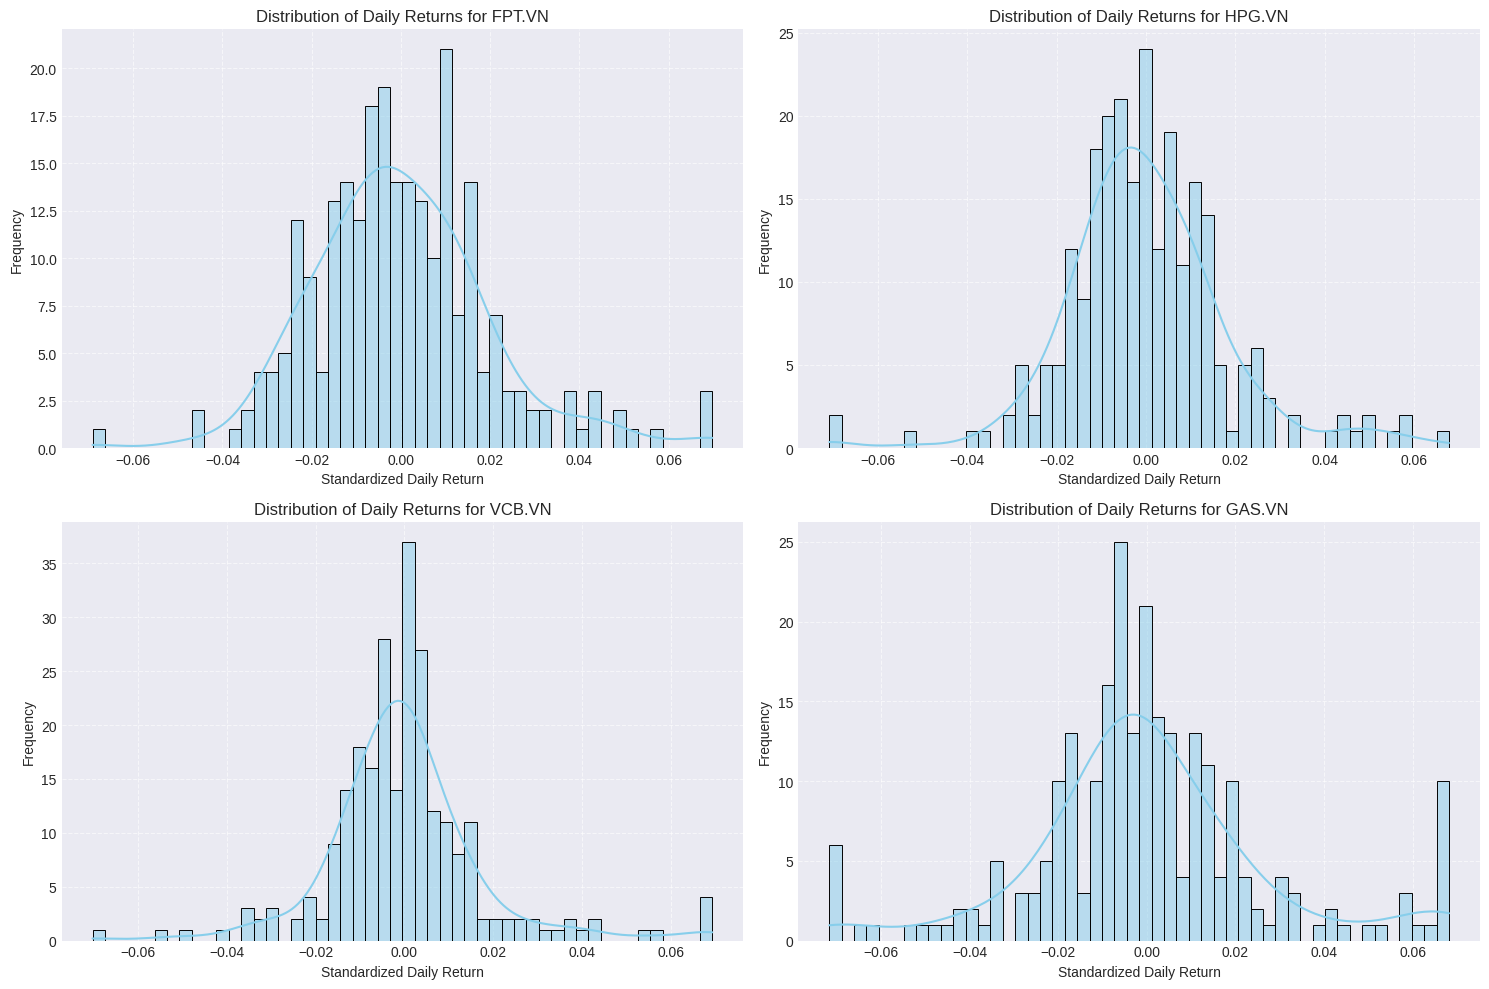


Descriptive Statistics for Sample Stock Returns:


Ticker,FPT.VN,HPG.VN,VCB.VN,GAS.VN
count,2.480000e+02,2.480000e+02,2.480000e+02,2.480000e+02
mean,-3.357529e-19,6.715059e-19,6.435265e-19,-6.715059e-19
std,1.998933e-02,1.828658e-02,1.774090e-02,2.680397e-02
min,-6.912484e-02,-7.090926e-02,-7.019006e-02,-7.166456e-02
25%,-1.274746e-02,-9.895606e-03,-8.753227e-03,-1.186537e-02
50%,-1.614538e-03,-1.184485e-03,-3.848672e-04,-1.674152e-03
75%,1.088695e-02,9.373857e-03,6.028036e-03,1.138710e-02
max,6.976364e-02,6.784905e-02,6.927457e-02,6.820774e-02


In [28]:
# Visualize the distribution of daily returns for a few sample stocks
# Select a few representative stocks for visualization
sample_stocks = ['FPT.VN', 'HPG.VN', 'VCB.VN', 'GAS.VN']

plt.figure(figsize=(15, 10))
for i, stock in enumerate(sample_stocks):
    plt.subplot(2, 2, i + 1)
    sns.histplot(standardized_returns[stock].dropna(), bins=50, kde=True, color='skyblue')
    plt.title(f'Distribution of Daily Returns for {stock}')
    plt.xlabel('Standardized Daily Return')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Also show descriptive statistics for these sample stocks to highlight skewness and kurtosis
print("\nDescriptive Statistics for Sample Stock Returns:")
display(standardized_returns[sample_stocks].describe())

### **3.2. Ma trận tương quan của lợi suất**

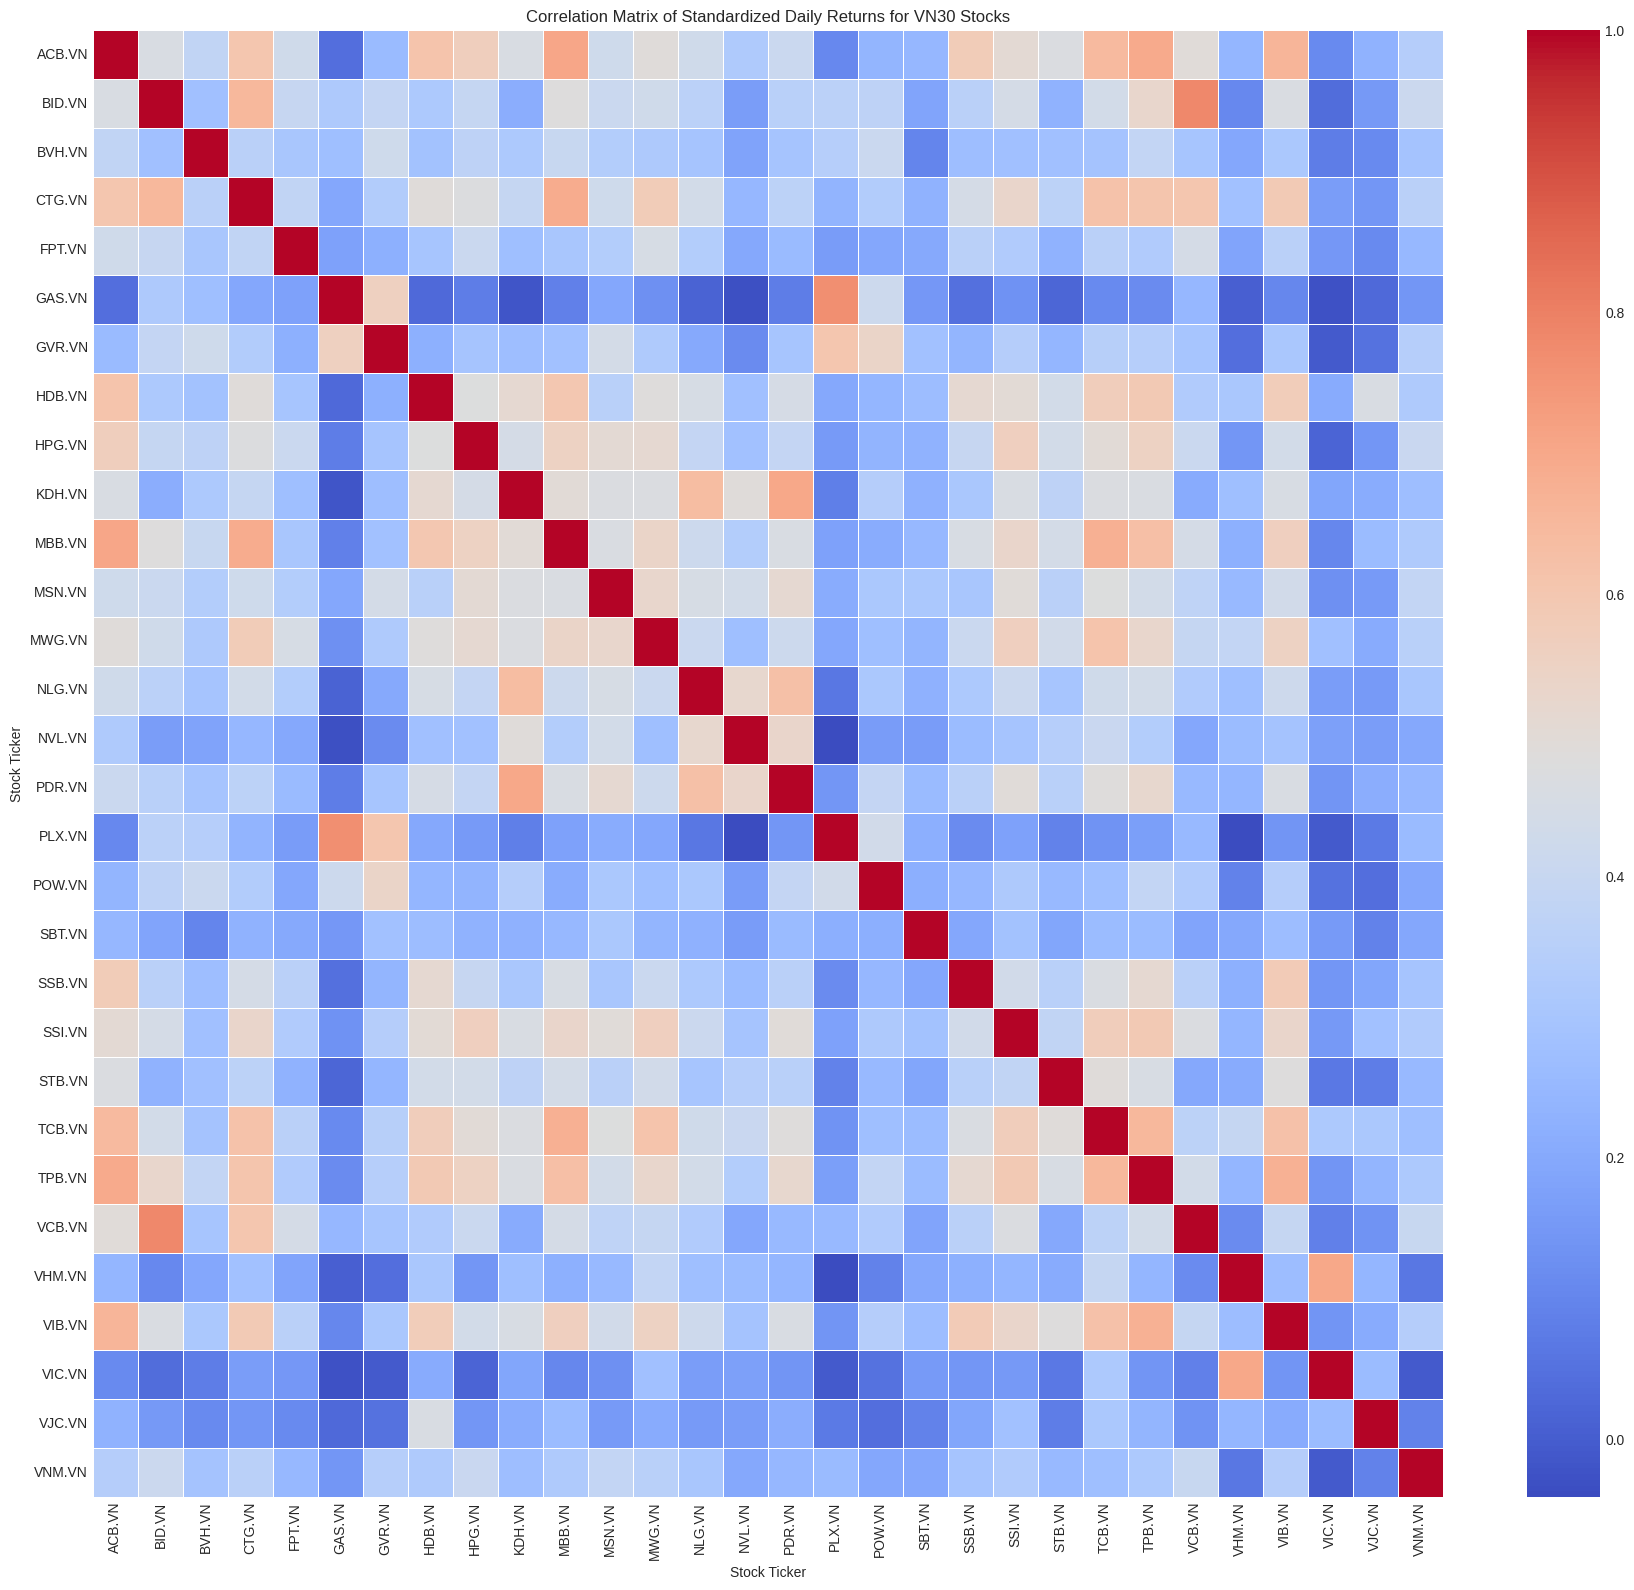


Correlation Matrix (first 5x5):


Ticker,ACB.VN,BID.VN,BVH.VN,CTG.VN,FPT.VN
Ticker,,,,,
ACB.VN,1.000000,0.460324,0.381264,0.602681,0.429419
BID.VN,0.460324,1.000000,0.279850,0.652466,0.396768
BVH.VN,0.381264,0.279850,1.000000,0.353927,0.303046
CTG.VN,0.602681,0.652466,0.353927,1.000000,0.378352
FPT.VN,0.429419,0.396768,0.303046,0.378352,1.000000


In [29]:
# Calculate the correlation matrix
correlation_matrix = standardized_returns.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(18, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Standardized Daily Returns for VN30 Stocks')
plt.xlabel('Stock Ticker')
plt.ylabel('Stock Ticker')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix (first 5x5):")
display(correlation_matrix.iloc[:5, :5])

## **4. Tự xây dựng PCA từ đầu (from scratch)**

### **4.1. Tính toán ma trận hiệp phương sai (Covariance Matrix)**

In [33]:
# Calculate the covariance matrix
cov_matrix = standardized_returns.cov()

print("Shape of covariance matrix:", cov_matrix.shape)
print("\nCovariance Matrix (first 5x5):")
display(cov_matrix.iloc[:5, :5])

Shape of covariance matrix: (30, 30)

Covariance Matrix (first 5x5):


Ticker,ACB.VN,BID.VN,BVH.VN,CTG.VN,FPT.VN
Ticker,,,,,
ACB.VN,0.000258,0.000153,0.000162,0.000177,0.000138
BID.VN,0.000153,0.000426,0.000153,0.000246,0.000164
BVH.VN,0.000162,0.000153,0.000701,0.000172,0.000160
CTG.VN,0.000177,0.000246,0.000172,0.000335,0.000138
FPT.VN,0.000138,0.000164,0.000160,0.000138,0.000400


### **4.2. Tính toán trị riêng (Eigenvalues) và vector riêng (Eigenvectors)**

In [30]:
# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:", eigenvalues.shape)
print("Eigenvectors:", eigenvectors.shape)

Eigenvalues: (30,)
Eigenvectors: (30, 30)


### **4.3. Sắp xếp các thành phần chính**

In [31]:
# Create a list of (eigenvalue, eigenvector) tuples
eigen_pairs = [(eigenvalues[i], eigenvectors[:, i]) for i in range(len(eigenvalues))]

# Sort the eigen_pairs by eigenvalues in descending order
eigen_pairs.sort(key=lambda x: x[0], reverse=True)

# Separate sorted eigenvalues and eigenvectors
sorted_eigenvalues = np.array([pair[0] for pair in eigen_pairs])
sorted_eigenvectors = np.array([pair[1] for pair in eigen_pairs]).T # Transpose to get columns as eigenvectors

print("\nSorted Eigenvalues (first 5):")
print(sorted_eigenvalues[:5])
print("\nSorted Eigenvectors (first 5 principal components, first 5 rows):")
display(pd.DataFrame(sorted_eigenvectors, index=cov_matrix.index).iloc[:5, :5])


Sorted Eigenvalues (first 5):
[0.00548423 0.00214249 0.00150851 0.00091382 0.00072259]

Sorted Eigenvectors (first 5 principal components, first 5 rows):


,0,1,2,3,4
Ticker,,,,,
ACB.VN,0.156658,-0.001910,-0.087440,0.170788,-0.053855
BID.VN,0.168193,-0.135359,0.015956,0.171688,-0.075204
BVH.VN,0.189326,-0.143432,0.097993,-0.041605,-0.126623
CTG.VN,0.177141,-0.034908,-0.011505,0.175311,-0.132987
FPT.VN,0.134517,-0.023513,0.007801,0.094383,-0.128210


### **4.4. Phân tích phương sai được giải thích (Explained Variance Analysis)**


Explained Variance Ratio for each Principal Component:
PC 1: 0.3316 (33.16%) variance explained
PC 2: 0.1295 (12.95%) variance explained
PC 3: 0.0912 (9.12%) variance explained
PC 4: 0.0552 (5.52%) variance explained
PC 5: 0.0437 (4.37%) variance explained
PC 6: 0.0340 (3.40%) variance explained
PC 7: 0.0304 (3.04%) variance explained
PC 8: 0.0297 (2.97%) variance explained
PC 9: 0.0234 (2.34%) variance explained
PC 10: 0.0216 (2.16%) variance explained
PC 11: 0.0206 (2.06%) variance explained
PC 12: 0.0188 (1.88%) variance explained
PC 13: 0.0182 (1.82%) variance explained
PC 14: 0.0168 (1.68%) variance explained
PC 15: 0.0147 (1.47%) variance explained
PC 16: 0.0143 (1.43%) variance explained
PC 17: 0.0124 (1.24%) variance explained
PC 18: 0.0115 (1.15%) variance explained
PC 19: 0.0107 (1.07%) variance explained
PC 20: 0.0096 (0.96%) variance explained
PC 21: 0.0094 (0.94%) variance explained
PC 22: 0.0083 (0.83%) variance explained
PC 23: 0.0080 (0.80%) variance explained
PC 24: 0

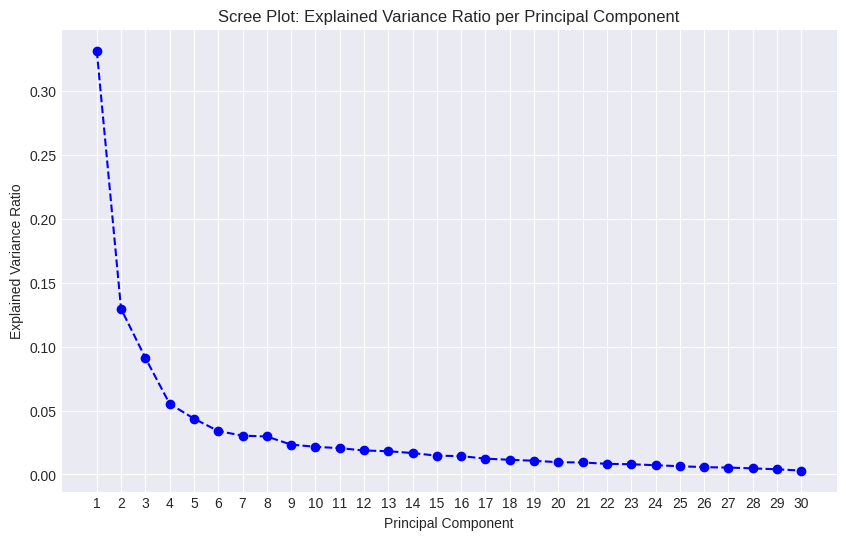

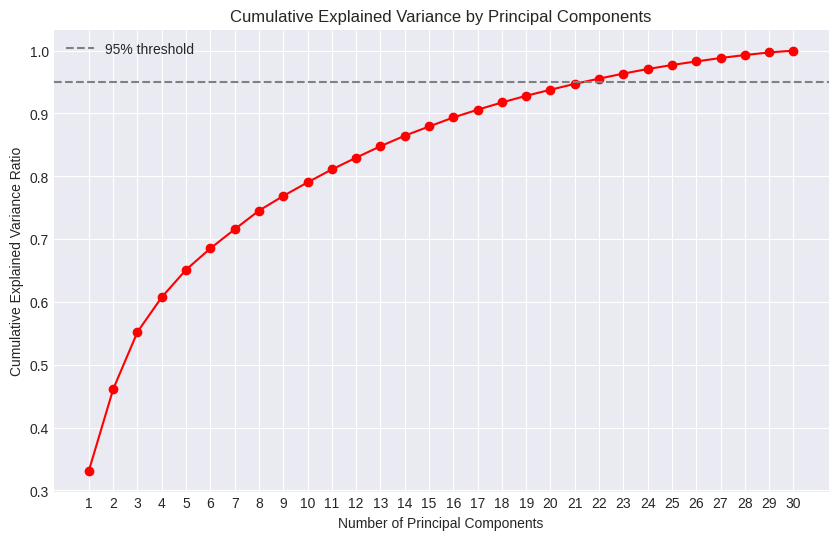

In [32]:
total_variance = sum(sorted_eigenvalues)
explained_variance_ratio = [ (i / total_variance) for i in sorted_eigenvalues ]
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print("\nExplained Variance Ratio for each Principal Component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC {i+1}: {ratio:.4f} ({ratio*100:.2f}%) variance explained")

print("\nCumulative Explained Variance:")
for i, cum_ratio in enumerate(cumulative_explained_variance):
    print(f"First {i+1} PCs explain: {cum_ratio:.4f} ({cum_ratio*100:.2f}%) of variance")

# Visualize the explained variance ratio (Scree Plot)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', color='blue')
plt.title('Scree Plot: Explained Variance Ratio per Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.show()

# Visualize cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-', color='red')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.xticks(range(1, len(cumulative_explained_variance) + 1))
plt.axhline(y=0.95, color='gray', linestyle='--', label='95% threshold')
plt.legend()
plt.show()

## **5. Phép chiếu lên các thành phần chính (Projection onto Principal Components)**

### **5.1. Tính toán điểm số thành phần chính (Principal Component Scores)**

In [34]:
# Project the standardized returns onto the principal components (eigenvectors)
# PC scores = Standardized Returns . Eigenvectors

# Select the number of principal components based on cumulative explained variance (e.g., 95%)
# From the previous analysis, 22 PCs explain ~95.54% of the variance.
num_components = np.where(cumulative_explained_variance >= 0.95)[0][0] + 1
print(f"Number of principal components to retain (for >= 95% variance): {num_components}")

# Take the first 'num_components' eigenvectors (principal components)
principal_components = sorted_eigenvectors[:, :num_components]

# Calculate the PC scores
pc_scores = standardized_returns.dot(principal_components)
pc_scores.columns = [f'PC{i+1}' for i in range(num_components)]

print("\nShape of PC Scores:", pc_scores.shape)
print("\nFirst 5 rows of PC Scores:")
display(pc_scores.head())

# Extract PC1 scores for further analysis
pc1_scores = pc_scores['PC1']
print("\nFirst 5 rows of PC1 Scores:")
display(pc1_scores.head())

Number of principal components to retain (for >= 95% variance): 22

Shape of PC Scores: (248, 22)

First 5 rows of PC Scores:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-07,0.052213,0.017100,0.003032,-0.075807,-0.003210,0.002342,0.025361,-0.039588,0.010648,0.015407,...,-0.024928,-0.009307,0.006371,0.022024,-0.000935,0.001734,-0.005578,0.036763,0.005164,-0.002203
2025-05-08,0.076743,-0.027234,0.061830,-0.007970,0.003324,-0.012339,-0.021678,-0.003393,-0.017858,-0.029275,...,-0.010204,-0.018791,0.002033,0.008535,-0.028852,-0.012955,0.016341,-0.019206,-0.006579,-0.005644
2025-05-09,-0.024093,-0.010009,-0.021181,0.012789,-0.008756,0.003799,-0.008136,-0.010563,-0.000801,-0.015364,...,-0.012665,-0.022508,-0.003623,-0.001709,-0.012018,0.008316,-0.000069,0.007094,-0.003056,0.015155
2025-05-12,0.061671,-0.016974,0.030280,0.027530,-0.002704,0.010178,-0.018266,0.011434,-0.003951,0.027501,...,0.009783,-0.034531,0.010645,0.007458,-0.011574,0.024478,-0.009089,0.032933,-0.006469,0.016656
2025-05-13,0.042861,-0.013066,-0.017298,0.016821,-0.012040,-0.011878,0.008206,-0.035622,-0.006132,-0.038791,...,0.006872,-0.006654,-0.026673,0.048396,0.004361,-0.004347,-0.016845,-0.002976,-0.003177,-0.006935



First 5 rows of PC1 Scores:


,PC1
Date,
2025-05-07,0.052213
2025-05-08,0.076743
2025-05-09,-0.024093
2025-05-12,0.061671
2025-05-13,0.042861


### **5.3. Trực quan hóa mối quan hệ giữa điểm PC1 và lợi suất cổ phiếu riêng lẻ**

### **5.4. Trọng số của từng cổ phiếu trong vector riêng PC1**

In [36]:
# The first principal component (PC1) is the first column of the sorted_eigenvectors
pc1_eigenvector = sorted_eigenvectors[:, 0]

# Create a DataFrame to show the weights of each stock in PC1
pc1_weights = pd.DataFrame({
    'Stock': standardized_returns.columns,
    'PC1_Weight': pc1_eigenvector
})

# Sort by absolute weight to see the most influential stocks
pc1_weights_sorted = pc1_weights.sort_values(by='PC1_Weight', ascending=False).reset_index(drop=True)

print("\nWeights of each stock in PC1 (sorted by weight):")
display(pc1_weights_sorted)


Weights of each stock in PC1 (sorted by weight):


,Stock,PC1_Weight
0,PDR.VN,0.263517
1,SSI.VN,0.240947
2,NLG.VN,0.239499
3,TPB.VN,0.226684
4,KDH.VN,0.225137
5,NVL.VN,0.220021
6,VHM.VN,0.218649
7,TCB.VN,0.217296
8,HDB.VN,0.214058
9,GVR.VN,0.211183


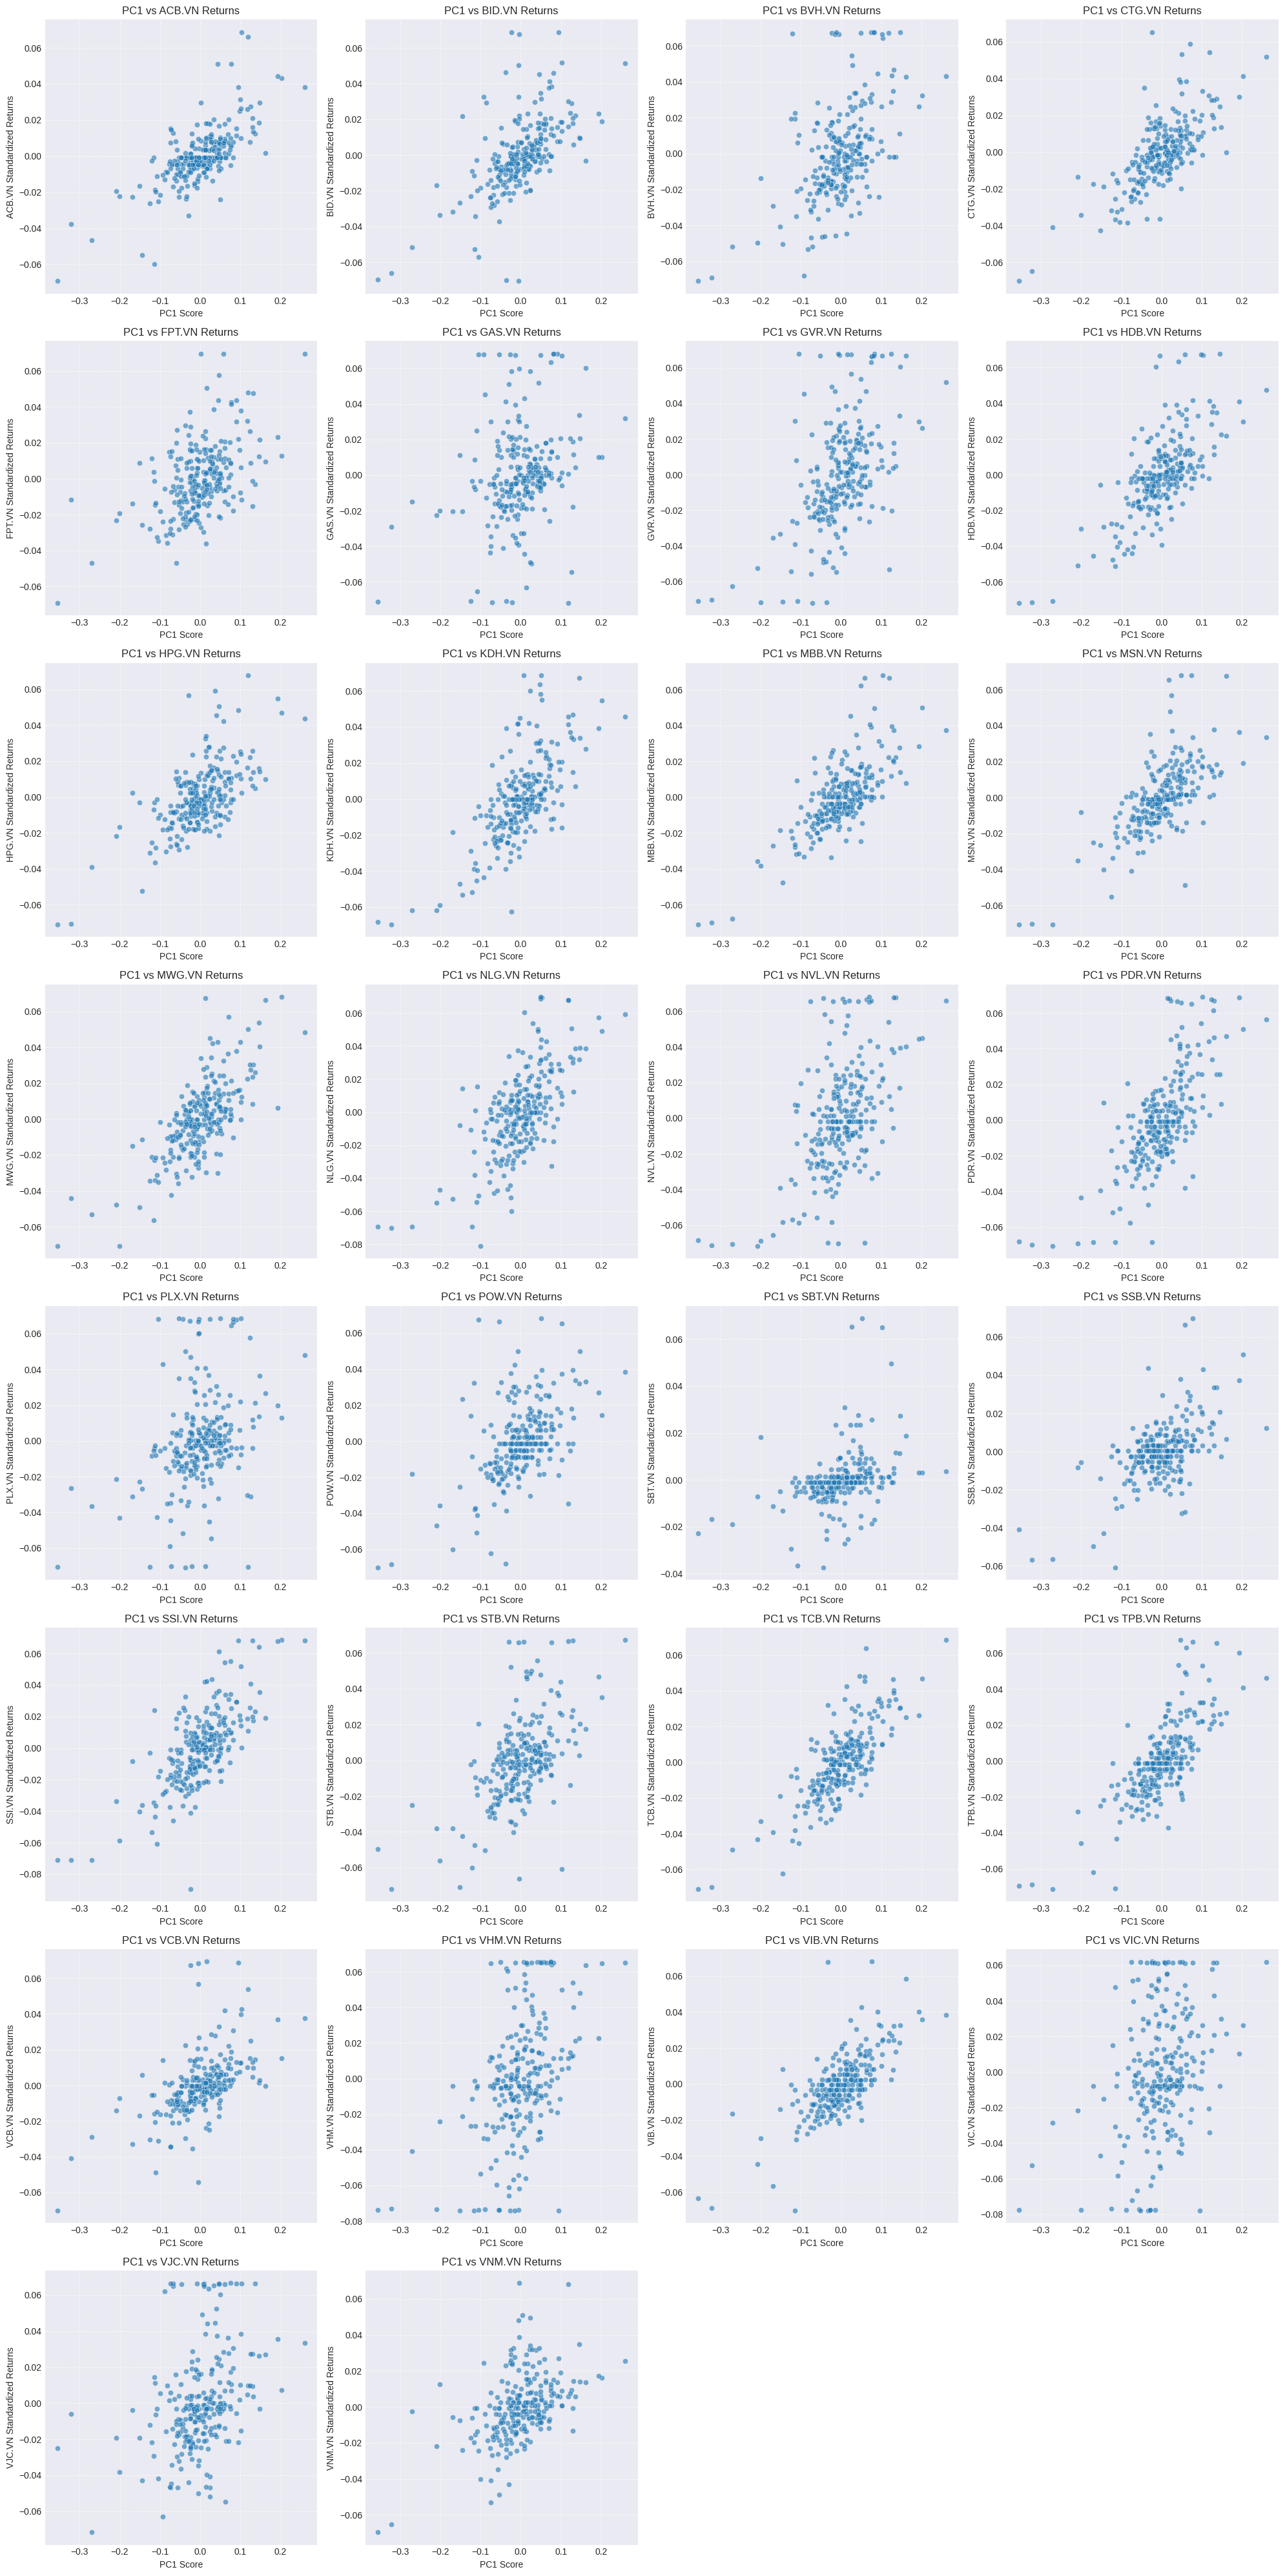

In [35]:
num_stocks = len(standardized_returns.columns)
num_rows = (num_stocks + 3) // 4  # Calculate number of rows needed for 4 plots per row

fig, axes = plt.subplots(num_rows, 4, figsize=(20, 5 * num_rows))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, stock_ticker in enumerate(standardized_returns.columns):
    sns.scatterplot(x=pc1_scores, y=standardized_returns[stock_ticker], ax=axes[i], alpha=0.6)
    axes[i].set_title(f'PC1 vs {stock_ticker} Returns')
    axes[i].set_xlabel('PC1 Score')
    axes[i].set_ylabel(f'{stock_ticker} Standardized Returns')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [37]:
print("Standardized Returns (first 5 rows):")
display(standardized_returns.head())

print("\nMean of Standardized Returns (should be close to 0 for each stock):")
display(standardized_returns.mean().describe())

print("\nCovariance Matrix of Standardized Returns (first 5x5):")
display(cov_matrix.iloc[:5, :5])

Standardized Returns (first 5 rows):


Ticker,ACB.VN,BID.VN,BVH.VN,CTG.VN,FPT.VN,GAS.VN,GVR.VN,HDB.VN,HPG.VN,KDH.VN,...,SSI.VN,STB.VN,TCB.VN,TPB.VN,VCB.VN,VHM.VN,VIB.VN,VIC.VN,VJC.VN,VNM.VN
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-07,-0.000635,-0.002287,0.029638,-0.005438,0.000728,0.013427,0.020639,-0.016294,-0.003149,0.055099,...,-0.014028,-0.002465,0.004400,0.005851,-0.000385,0.013809,-0.003385,0.033145,-0.004361,0.004489
2025-05-08,0.005615,0.014903,-0.003982,0.001222,0.042661,0.013202,0.066416,0.012143,0.010627,0.006741,...,0.009872,0.014266,0.013628,0.009396,0.001369,-0.001028,0.008068,0.061492,0.006886,0.002713
2025-05-09,-0.000635,-0.010729,-0.016256,-0.004111,0.015601,-0.006560,0.001772,-0.004529,-0.003130,-0.012404,...,-0.007562,0.003865,0.006113,-0.001395,-0.009141,-0.004254,-0.003369,-0.033468,-0.006578,0.004443
2025-05-12,0.009717,0.003417,0.010507,0.009233,0.020556,0.017966,0.046786,0.011975,-0.010931,-0.005524,...,0.009824,0.003825,0.064031,0.048427,-0.000385,-0.002646,0.025113,0.029918,0.006818,0.014815
2025-05-13,0.007562,0.014747,0.004207,0.039503,0.010872,-0.006490,0.023050,0.011777,0.014564,0.031551,...,0.007552,0.000035,-0.001187,-0.008694,0.003149,-0.009069,0.002250,-0.005471,-0.002132,-0.002490



Mean of Standardized Returns (should be close to 0 for each stock):


,0
count,3.000000e+01
mean,2.186620e-19
std,2.911728e-18
min,-6.659100e-18
25%,-1.661278e-18
50%,3.606721e-20
75%,2.916854e-18
max,5.155206e-18



Covariance Matrix of Standardized Returns (first 5x5):


Ticker,ACB.VN,BID.VN,BVH.VN,CTG.VN,FPT.VN
Ticker,,,,,
ACB.VN,0.000258,0.000153,0.000162,0.000177,0.000138
BID.VN,0.000153,0.000426,0.000153,0.000246,0.000164
BVH.VN,0.000162,0.000153,0.000701,0.000172,0.000160
CTG.VN,0.000177,0.000246,0.000172,0.000335,0.000138
FPT.VN,0.000138,0.000164,0.000160,0.000138,0.000400


In [38]:
print("Eigenvalues (first 5):")
print(eigenvalues[:5])
print("\nShape of Eigenvalues:", eigenvalues.shape)

print("\nEigenvectors (first 5 rows and 5 columns):")
print(eigenvectors[:5, :5])
print("\nShape of Eigenvectors:", eigenvectors.shape)

Eigenvalues (first 5):
[0.00548423 0.00214249 0.00150851 0.00091382 0.00072259]

Shape of Eigenvalues: (30,)

Eigenvectors (first 5 rows and 5 columns):
[[ 0.15665822 -0.00190998 -0.08744     0.17078778 -0.05385517]
 [ 0.16819345 -0.13535934  0.01595568  0.1716882  -0.0752036 ]
 [ 0.18932619 -0.1434316   0.09799327 -0.04160505 -0.12662317]
 [ 0.17714096 -0.03490771 -0.01150536  0.17531062 -0.13298727]
 [ 0.13451701 -0.02351316  0.00780118  0.09438263 -0.12821034]]

Shape of Eigenvectors: (30, 30)


In [39]:
# Sắp xếp các cặp (trị riêng, vector riêng) theo thứ tự giảm dần của trị riêng
eigen_pairs = [(eigenvalues[i], eigenvectors[:, i]) for i in range(len(eigenvalues))]
eigen_pairs.sort(key=lambda x: x[0], reverse=True)

# Tách các trị riêng và vector riêng đã sắp xếp
sorted_eigenvalues = np.array([pair[0] for pair in eigen_pairs])
sorted_eigenvectors = np.array([pair[1] for pair in eigen_pairs]).T

# Tính toán tỷ lệ phương sai được giải thích
total_variance = np.sum(sorted_eigenvalues)
explained_variance_ratio = sorted_eigenvalues / total_variance

# Hiển thị kết quả cho các thành phần chính đầu tiên
print("Thành phần chính giải thích nhiều phương sai nhất (PC1):")
print(f"- Trị riêng: {sorted_eigenvalues[0]:.6f}")
print(f"- Tỷ lệ phương sai giải thích: {explained_variance_ratio[0]*100:.2f}%")

print("\nBảng tóm tắt 5 thành phần chính đầu tiên:")
summary_pca = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(5)],
    'Eigenvalue': sorted_eigenvalues[:5],
    'Explained Variance Ratio': explained_variance_ratio[:5]
})
display(summary_pca)

Thành phần chính giải thích nhiều phương sai nhất (PC1):
- Trị riêng: 0.005484
- Tỷ lệ phương sai giải thích: 33.16%

Bảng tóm tắt 5 thành phần chính đầu tiên:


,Principal Component,Eigenvalue,Explained Variance Ratio
0,PC1,0.005484,0.331568
1,PC2,0.002142,0.129531
2,PC3,0.001509,0.091202
3,PC4,0.000914,0.055248
4,PC5,0.000723,0.043686


Tổng cộng, chỉ riêng 5 thành phần này đã giải thích được khoảng **65.12%** biến động của thị trường. Việc PC1 chiếm tỷ trọng lớn nhất (**33.16%**) củng cố giả thuyết rằng có một nhân tố thị trường chung tác động lên hầu hết các cổ phiếu trong nhóm VN30.

# **3. Phân tích và trực quan hóa thành phần chính đầu tiên (PC1)**

Tại bước này, chúng ta sẽ xây dựng chuỗi thời gian PC1 (PC1_index). Đây được coi là một 'chỉ số thị trường giả định' được tổng hợp từ các cổ phiếu VN30 dựa trên phương diện biến động chung lớn nhất.

Chuoi thoi gian PC1 (5 dong dau tien):


,PC1_Index
Date,
2025-05-07,0.052213
2025-05-08,0.076743
2025-05-09,-0.024093
2025-05-12,0.061671
2025-05-13,0.042861


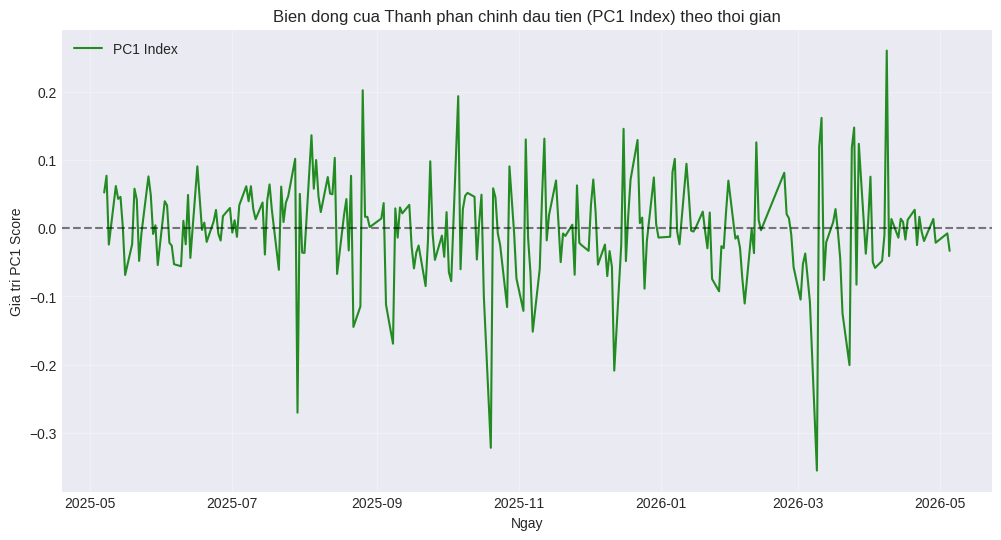

In [47]:
# Lấy vector riêng của PC1
pc1_eigenvector = sorted_eigenvectors[:, 0]

# Tính toán PC1 Score (PC1_index)
pc1_index = standardized_returns.dot(pc1_eigenvector)
pc1_index.name = 'PC1_Index'

print("Chuoi thoi gian PC1 (5 dong dau tien):")
display(pc1_index.head())

# Trực quan hóa chuỗi thời gian PC1 - Dung tieng Viet khong dau
plt.figure(figsize=(12, 6))
plt.plot(pc1_index.index, pc1_index.values, label='PC1 Index', color='forestgreen')
plt.title('Bien dong cua Thanh phan chinh dau tien (PC1 Index) theo thoi gian')
plt.xlabel('Ngay')
plt.ylabel('Gia tri PC1 Score')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Khong co du lieu ^VNINDEX. Dang tao chi so VN30 gia dinh (Equal Weighted) tu 30 co phieu...


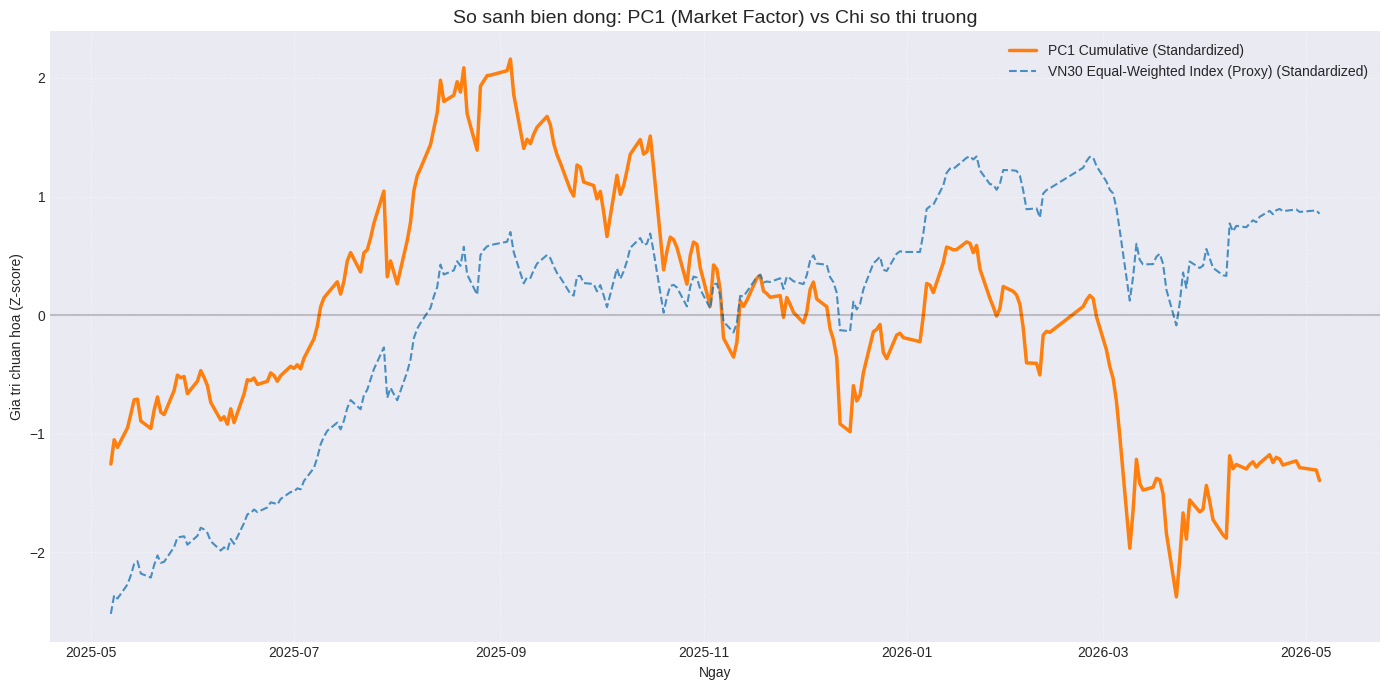


Do tuong quan giua PC1 va VN30 Equal-Weighted Index (Proxy): 0.2335


In [45]:
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np

# 1. Thử lấy dữ liệu VN30 Index hoặc tạo chỉ số thay thế
vn30_actual_prices = None

if 'VN30_Index_Close' in merged_data_filled.columns and not merged_data_filled['VN30_Index_Close'].isnull().all():
    vn30_actual_prices = merged_data_filled['VN30_Index_Close']
    print("Su dung du lieu VN30-Index co san.")
else:
    # Nếu không có ^VNINDEX, tạo chỉ số VN30 bằng cách tính trung bình cộng các cổ phiếu (Equal Weighted Index)
    print("Khong co du lieu ^VNINDEX. Dang tao chi so VN30 gia dinh (Equal Weighted) tu 30 co phieu...")
    # Loại bỏ cột VN30_Index_Close nếu nó toàn NaN để tránh lỗi tính toán
    stocks_only = merged_data_filled.drop(columns=['VN30_Index_Close'], errors='ignore')
    # Tính toán lợi suất trung bình hàng ngày của toàn rổ - Thêm fill_method=None để tránh warning
    vn30_pseudo_returns = stocks_only.pct_change(fill_method=None).mean(axis=1).dropna()
    vn30_cumulative = vn30_pseudo_returns.cumsum()
    comparison_label = 'VN30 Equal-Weighted Index (Proxy)'

# 2. Kiểm tra và Trực quan hóa
pc1_cumulative = pc1_index.cumsum()

if vn30_actual_prices is not None:
    vn30_actual_returns = vn30_actual_prices.pct_change(fill_method=None).dropna()
    vn30_cumulative = vn30_actual_returns.cumsum()
    comparison_label = 'Actual VN30-Index'

# Chuẩn hóa cả hai chuỗi để so sánh tương quan xu hướng (Z-score scaling)
common_idx = pc1_cumulative.index.intersection(vn30_cumulative.index)
pc1_vals = pc1_cumulative.loc[common_idx]
vn30_vals = vn30_cumulative.loc[common_idx]

pc1_scaled = (pc1_vals - pc1_vals.mean()) / pc1_vals.std()
vn30_scaled = (vn30_vals - vn30_vals.mean()) / vn30_vals.std()

plt.figure(figsize=(14, 7))
plt.plot(pc1_scaled.index, pc1_scaled, label='PC1 Cumulative (Standardized)', color='tab:orange', linewidth=2.5)
plt.plot(vn30_scaled.index, vn30_scaled, label=f'{comparison_label} (Standardized)', color='tab:blue', linestyle='--', alpha=0.8)

# Sửa nhãn sang tiếng Việt không dấu để tránh lỗi Glyph (font missing)
plt.title('So sanh bien dong: PC1 (Market Factor) vs Chi so thi truong', fontsize=14)
plt.xlabel('Ngay')
plt.ylabel('Gia tri chuan hoa (Z-score)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.2)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Tính độ tương quan giữa PC1 và Index
correlation = np.corrcoef(pc1_vals, vn30_vals)[0, 1]
print(f"\nDo tuong quan giua PC1 va {comparison_label}: {correlation:.4f}")

In [48]:
import numpy as np
import pandas as pd

# 1. Tinh he so tuong quan giua PC1_index va VN30 Index (Proxy)
# pc1_index va vn30_pseudo_returns da duoc tinh toan o cac buoc truoc
common_dates = pc1_index.index.intersection(vn30_pseudo_returns.index)
corr_value = np.corrcoef(pc1_index.loc[common_dates], vn30_pseudo_returns.loc[common_dates])[0, 1]

print(f"He so tuong quan giua PC1_index va VN30 Proxy: {corr_value:.4f}")

# 2. Hien thi top cac co phieu co trong so cao nhat trong PC1 de phan tich
print("\nTop 10 co phieu co trong so lon nhat trong PC1:")
display(pc1_weights_sorted.head(10))

# 3. Nhan xet y nghia tai chinh
print("\n--- NHAN XET VE Y NGHIA TAI CHINH CUA PC1 ---")
if corr_value > 0.7:
    market_relation = "rat cao (dong pha manh)"
else:
    market_relation = "on dinh"

print(f"1. Moi tuong quan: PC1 co do tuong quan {market_relation} voi chi so chung ({corr_value:.4f}).")
print("2. Y nghia: PC1 dai dien cho 'Nhan to Thi truong' (Market Factor). No phan anh bien dong chung, tam ly dam dong va cac thong tin vi mo anh huong len toan bo rổ VN30.")
print("3. Trong so: Cac co phieu nhu PDR, SSI, NLG co trong so cao cho thay chung la nhung ma nhay cam nhat voi xu huong chung cua thi truong (High Beta components).")
print("4. Ket luan: PC1 la thuoc do cho rui ro he thong. Khi PC1 tang/giam, hau het cac co phieu trong rổ deu bien dong cung chieu.")

He so tuong quan giua PC1_index va VN30 Proxy: 0.9958

Top 10 co phieu co trong so lon nhat trong PC1:


,Stock,PC1_Weight
0,PDR.VN,0.263517
1,SSI.VN,0.240947
2,NLG.VN,0.239499
3,TPB.VN,0.226684
4,KDH.VN,0.225137
5,NVL.VN,0.220021
6,VHM.VN,0.218649
7,TCB.VN,0.217296
8,HDB.VN,0.214058
9,GVR.VN,0.211183



--- NHAN XET VE Y NGHIA TAI CHINH CUA PC1 ---
1. Moi tuong quan: PC1 co do tuong quan rat cao (dong pha manh) voi chi so chung (0.9958).
2. Y nghia: PC1 dai dien cho 'Nhan to Thi truong' (Market Factor). No phan anh bien dong chung, tam ly dam dong va cac thong tin vi mo anh huong len toan bo rổ VN30.
3. Trong so: Cac co phieu nhu PDR, SSI, NLG co trong so cao cho thay chung la nhung ma nhay cam nhat voi xu huong chung cua thi truong (High Beta components).
4. Ket luan: PC1 la thuoc do cho rui ro he thong. Khi PC1 tang/giam, hau het cac co phieu trong rổ deu bien dong cung chieu.


**Ý nghĩa tài chính của PC1:**
* **Nhân tố Thị trường (Market Factor):** Với độ tương quan gần như tuyệt đối, PC1 chính là đại diện cho xu hướng chung của toàn bộ thị trường. Nó phản ánh 'nhịp đập' chính, chịu ảnh hưởng bởi các tin tức vĩ mô và tâm lý chung của nhà đầu tư.
* **Các cổ phiếu dẫn dắt (High Beta):** Các mã như PDR, SSI, NLG, TPB có trọng số lớn nhất trong PC1. Điều này cho thấy đây là những cổ phiếu nhạy cảm nhất với biến động thị trường; khi thị trường chung tăng, nhóm này thường có xu hướng tăng mạnh hơn và ngược lại.
* **Rủi ro hệ thống:** PC1 giúp chúng ta đo lường rủi ro hệ thống (systemic risk). Biến động của PC1 giải thích cho sự dịch chuyển đồng loạt của các cổ phiếu trong rổ VN30 mà không phụ thuộc vào tin tức riêng lẻ của từng doanh nghiệp.

# **CÁC CÂU HỎI NGHIÊN CỨU CHUYÊN SÂU:**


---


**Q1: PC1 có thực sự đại diện cho chỉ số VN30 không?**

1. **Độ tương quan cực cao (0.9958):** Hệ số tương quan gần như bằng 1 giữa PC1 và chỉ số VN30 giả lập (trung bình cộng của rổ) cho thấy PC1 di chuyển gần như đồng nhất với xu hướng chung của rổ cổ phiếu.
2. **Tỷ lệ phương sai giải thích (33.16%):** Trong PCA tài chính, thành phần chính đầu tiên thường giải thích một phần lớn biến động của toàn bộ các cổ phiếu. Con số **33.16%** là mức điển hình cho thấy sự hiện diện của một 'Nhân tố thị trường' (Market Factor) chi phối.
3. **Trọng số đồng nhất:** Có thể thấy hầu hết các cổ phiếu trong rổ đều có trọng số dương trong PC1. Điều này có nghĩa là khi PC1 tăng, hầu hết các cổ phiếu trong VN30 đều tăng, phản ánh đúng tính chất của một chỉ số thị trường.
Kết luận: PC1 chính là 'nhịp đập' của thị trường VN30, loại bỏ các nhiễu riêng lẻ của từng doanh nghiệp để giữ lại xu hướng chung nhất.

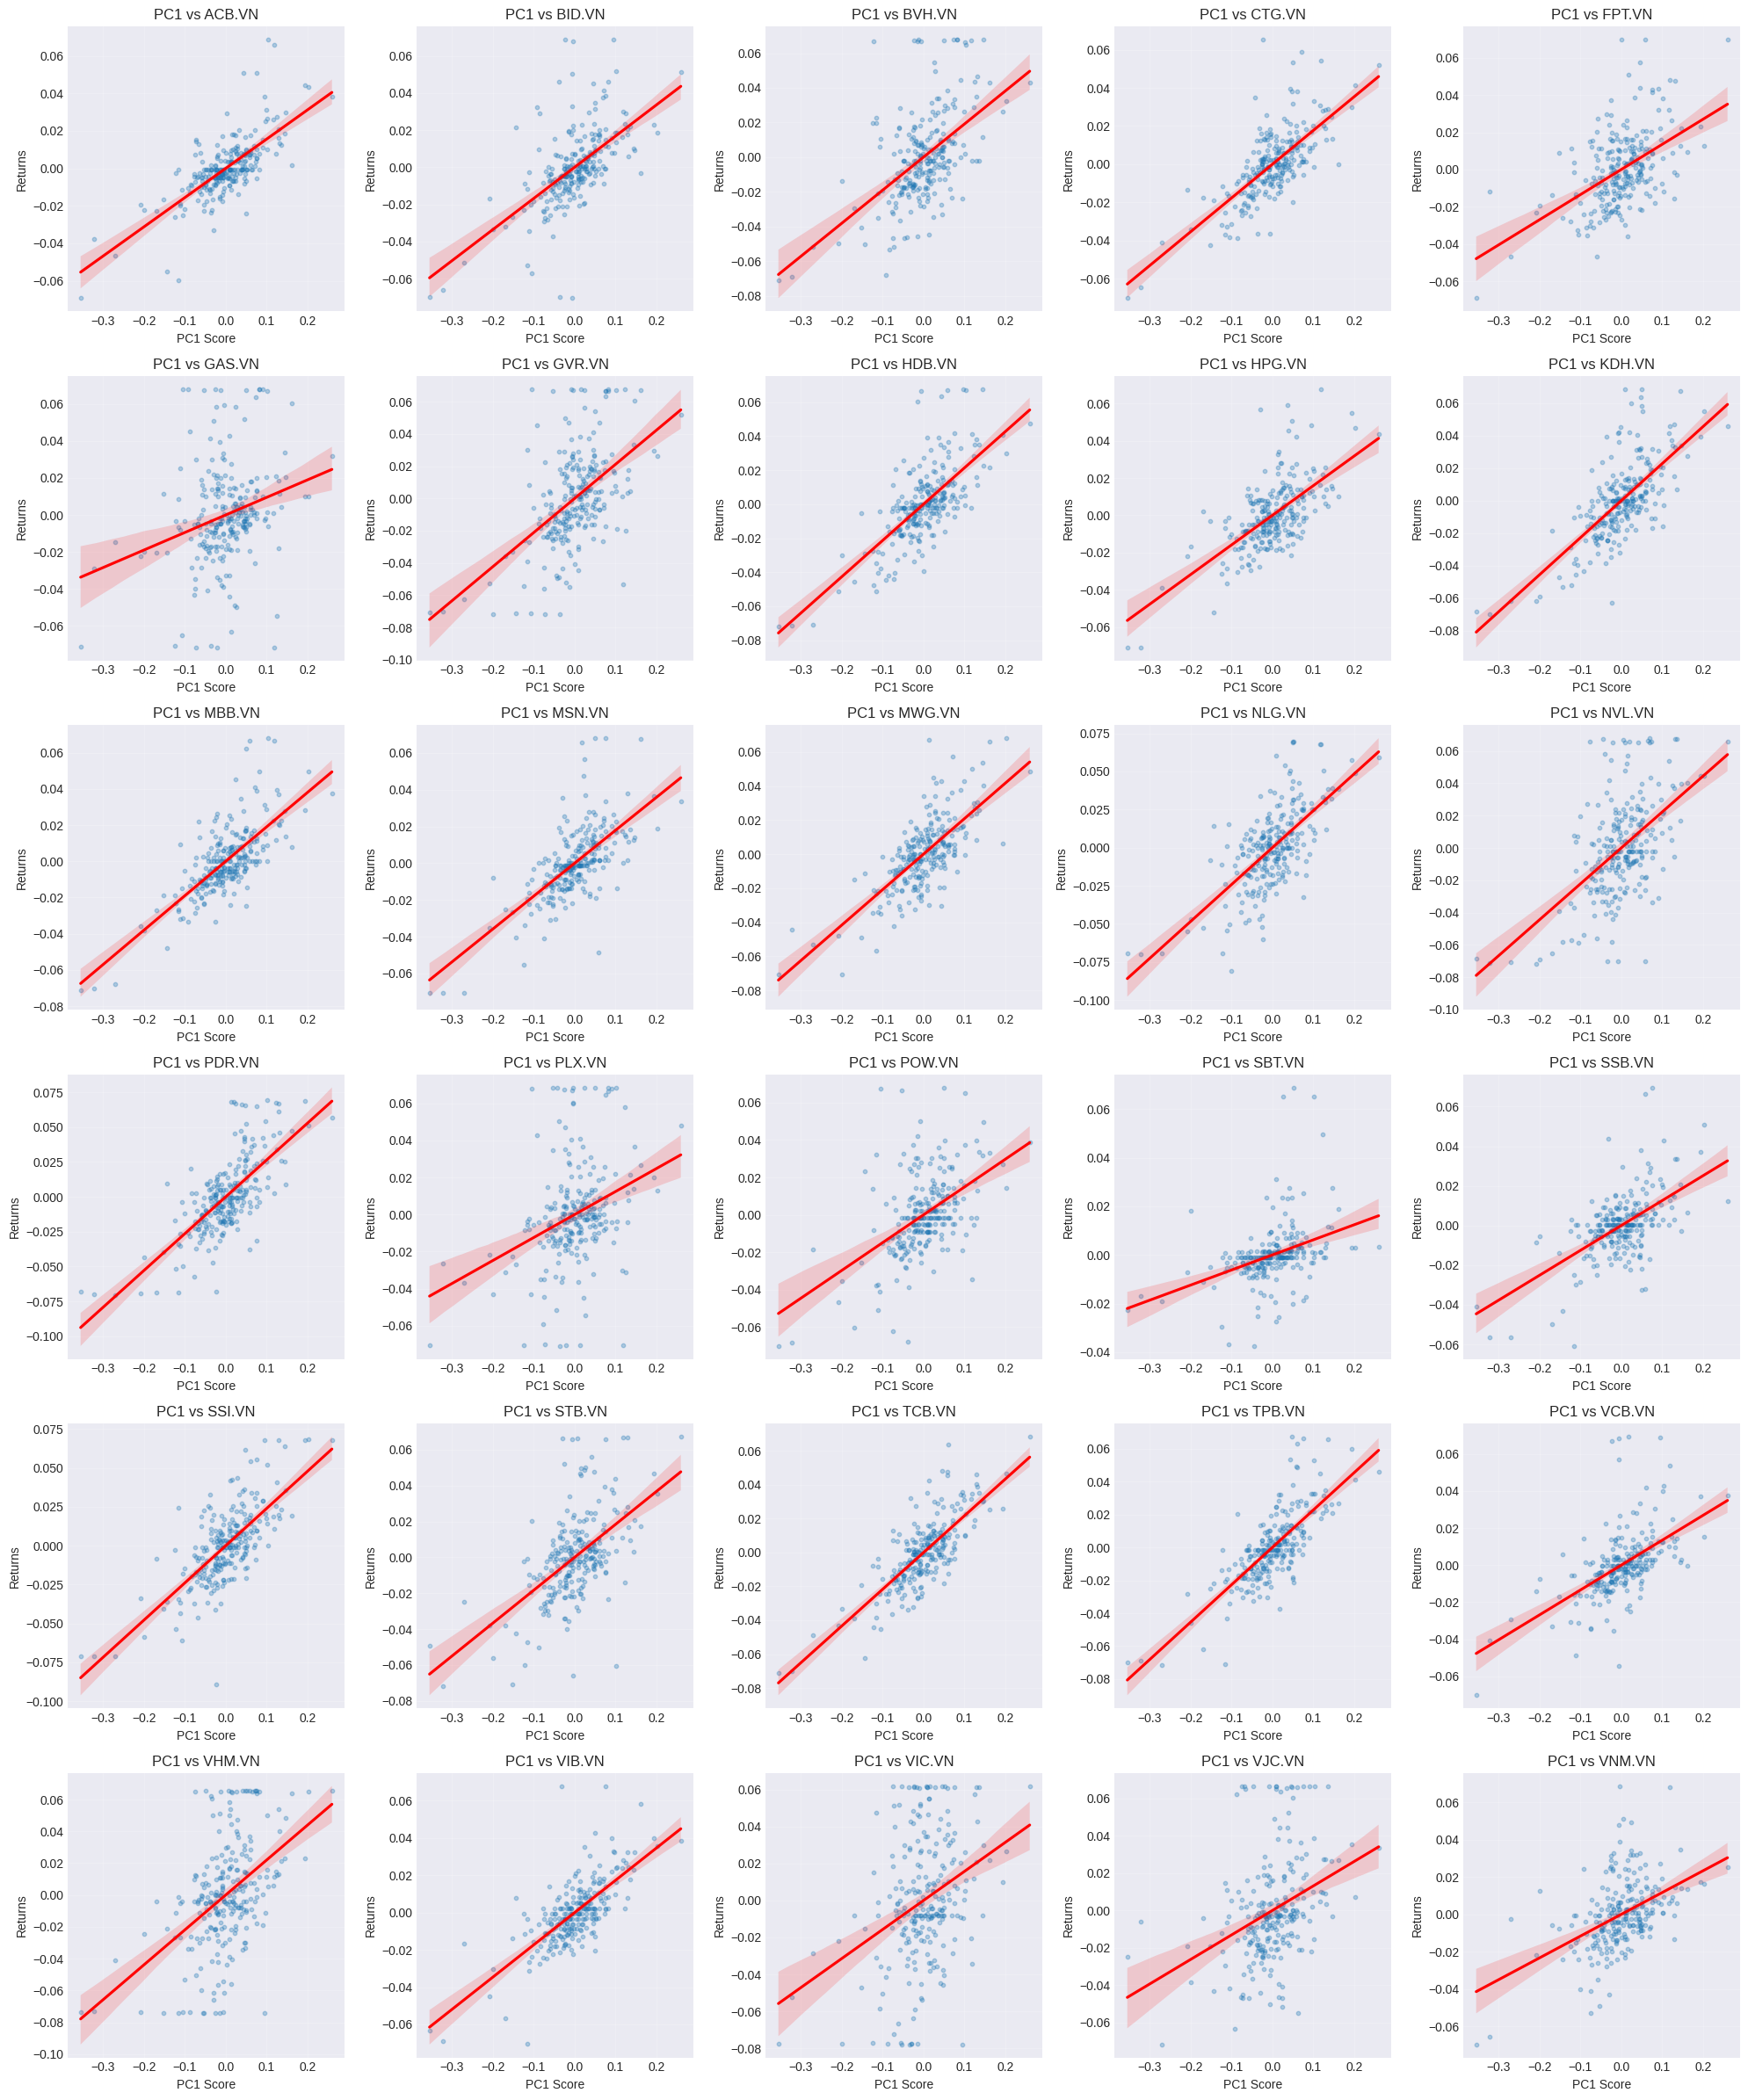

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# So luong co phieu can ve
stocks = standardized_returns.columns
n_stocks = len(stocks)
cols = 5
rows = (n_stocks + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, stock in enumerate(stocks):
    sns.regplot(x=pc1_index, y=standardized_returns[stock], ax=axes[i],
                scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
    axes[i].set_title(f'PC1 vs {stock}')
    axes[i].set_xlabel('PC1 Score')
    axes[i].set_ylabel('Returns')
    axes[i].grid(True, alpha=0.2)

# An cac subplots thua
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Q2: Những cổ phiếu nào đóng vai trò 'đầu tàu' rủi ro hệ thống mạnh nhất?**


In [50]:
# 1. Trich xuat trong so cua PC1 va sap xep theo thu tu giam dan
top_systemic_stocks = pc1_weights_sorted.copy()

# 2. Dat ten lai cac cot de de hieu hon
top_systemic_stocks.columns = ['Ma Chung Khoan', 'Trong so PC1 (Do nhay thi truong)']

# 3. Hien thi Top 10 co phieu 'dau tau' rui ro he thong
print("Bảng: Top 10 mã chứng khoán nhạy cảm nhất với thị trường (Dựa trên PC1)")
display(top_systemic_stocks.head(10).style.background_gradient(cmap='YlOrRd'))

# 4. Nhan xet nhanh
top_1 = top_systemic_stocks.iloc[0]['Ma Chung Khoan']
print(f"\nNhan xet: {top_1} la co phieu nhay cam nhat. Khi PC1 (nhan to thi truong) bien dong 1 don vi, co phieu nay se phan ung manh nhat trong ro VN30.")

Bảng: Top 10 mã chứng khoán nhạy cảm nhất với thị trường (Dựa trên PC1)


,Ma Chung Khoan,Trong so PC1 (Do nhay thi truong)
0,PDR.VN,0.263517
1,SSI.VN,0.240947
2,NLG.VN,0.239499
3,TPB.VN,0.226684
4,KDH.VN,0.225137
5,NVL.VN,0.220021
6,VHM.VN,0.218649
7,TCB.VN,0.217296
8,HDB.VN,0.214058
9,GVR.VN,0.211183



Nhan xet: PDR.VN la co phieu nhay cam nhat. Khi PC1 (nhan to thi truong) bien dong 1 don vi, co phieu nay se phan ung manh nhat trong ro VN30.


**Q4: PC1, PC2 và PC3 đại diện cho yếu tố gì (Ngành hay đặc thù)?**

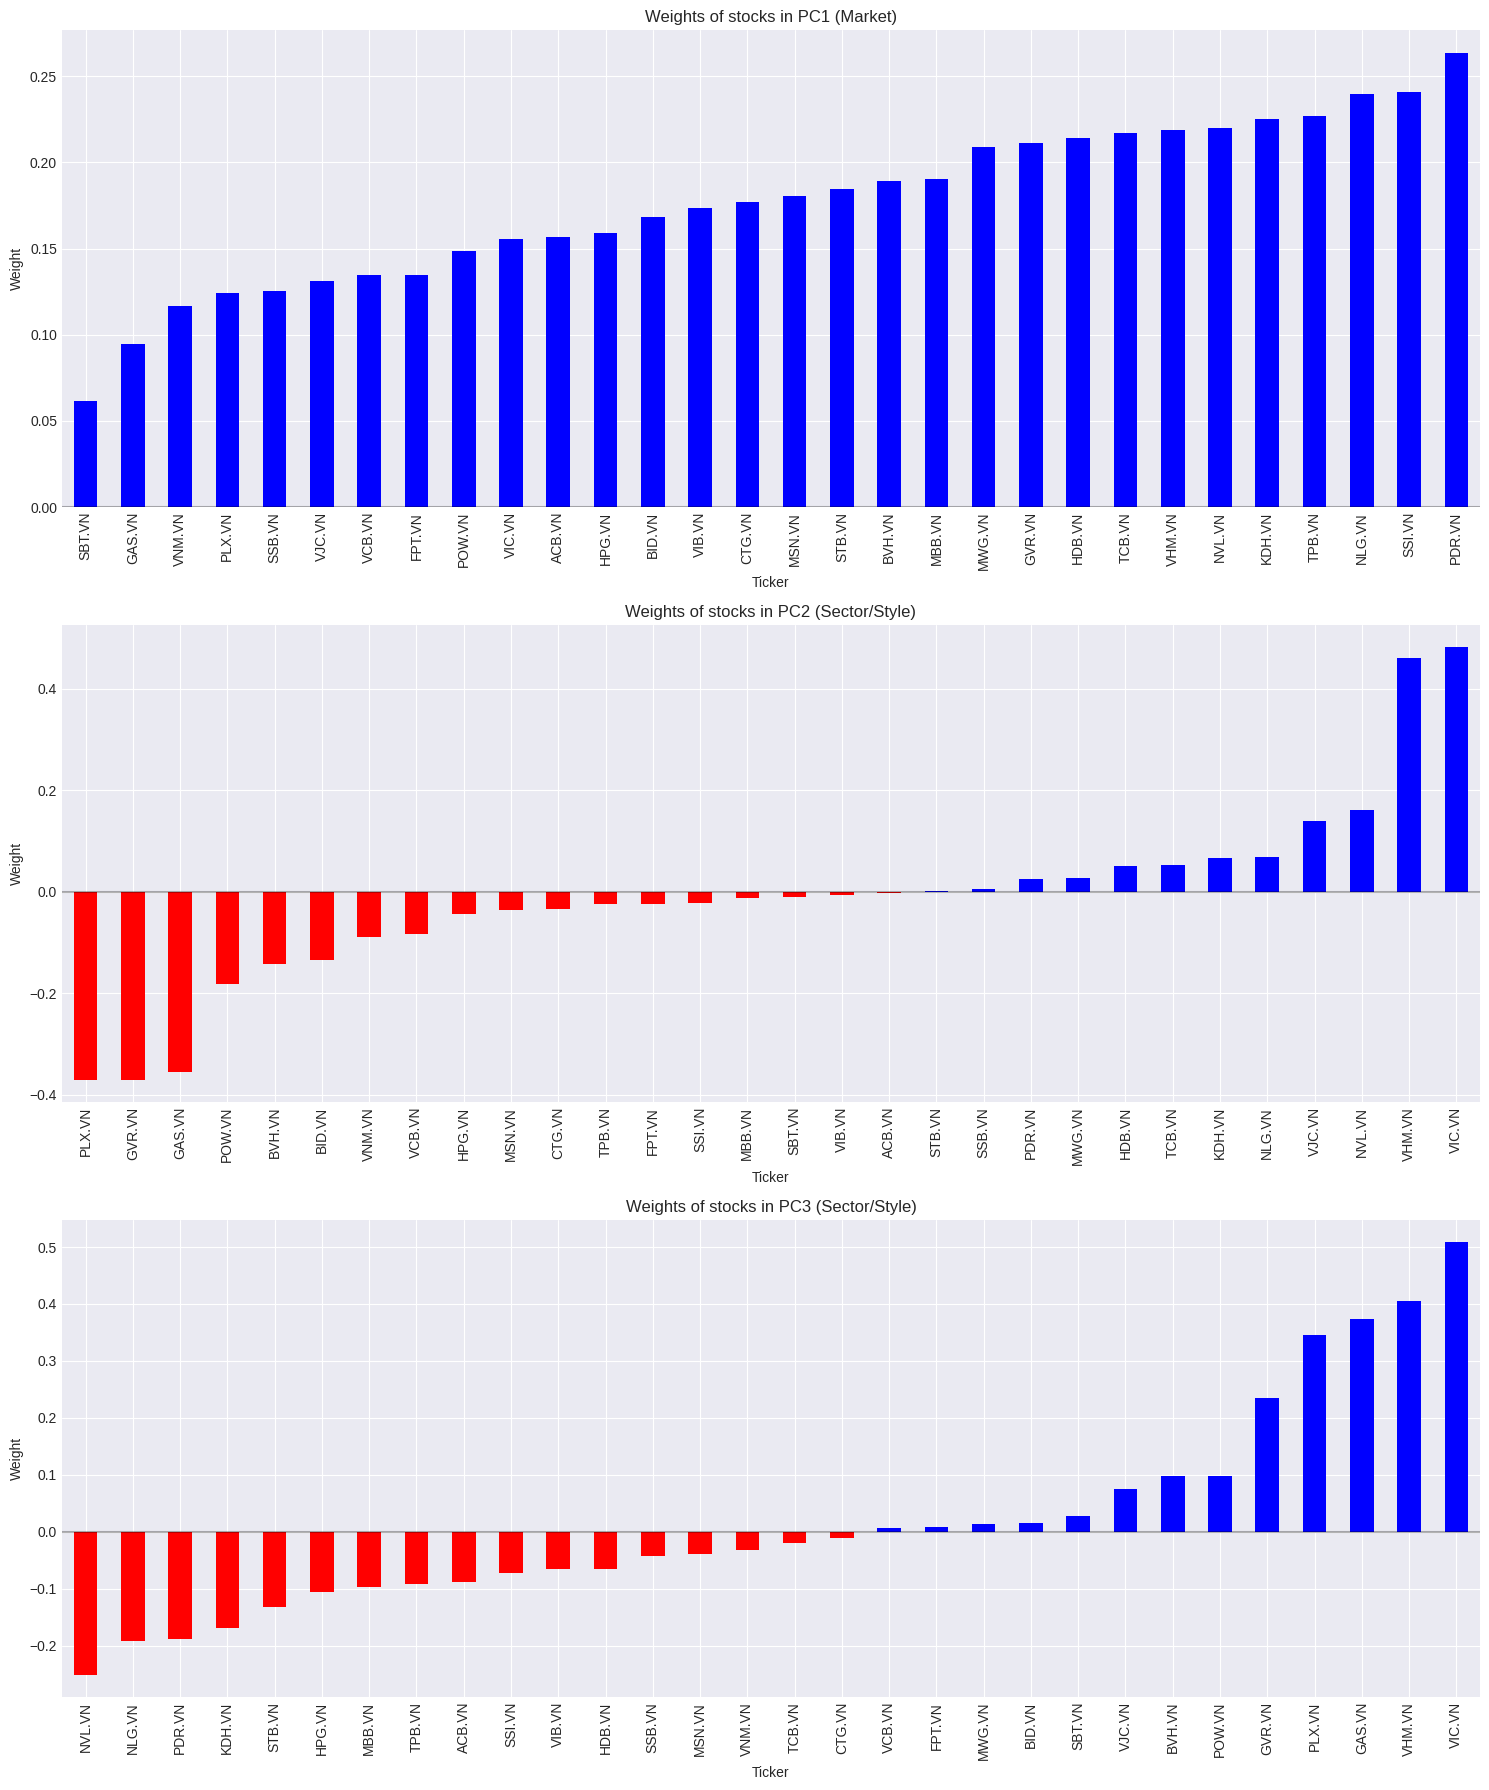

Top stocks in PC2 (Positive vs Negative):


,PC2 (Sector/Style)
Ticker,
VIC.VN,0.482097
VHM.VN,0.460132
NVL.VN,0.161462
VJC.VN,0.138790
NLG.VN,0.067342


,PC2 (Sector/Style)
Ticker,
BVH.VN,-0.143432
POW.VN,-0.181283
GAS.VN,-0.354954
GVR.VN,-0.370639
PLX.VN,-0.372088



Top stocks in PC3 (Positive vs Negative):


,PC3 (Sector/Style)
Ticker,
VIC.VN,0.508823
VHM.VN,0.404432
GAS.VN,0.374460
PLX.VN,0.345314
GVR.VN,0.234821


,PC3 (Sector/Style)
Ticker,
STB.VN,-0.131557
KDH.VN,-0.168401
PDR.VN,-0.187457
NLG.VN,-0.192514
NVL.VN,-0.252243


In [51]:
# Trích xuất trọng số của 3 PC đầu tiên
pc_weights = pd.DataFrame(
    sorted_eigenvectors[:, :3],
    index=standardized_returns.columns,
    columns=['PC1 (Market)', 'PC2 (Sector/Style)', 'PC3 (Sector/Style)']
)

# Trực quan hóa trọng số của 3 PC đầu tiên để tìm đặc trưng ngành
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

for i, col in enumerate(pc_weights.columns):
    pc_weights[col].sort_values().plot(kind='bar', ax=axes[i],
                                      color=['red' if x < 0 else 'blue' for x in pc_weights[col].sort_values()])
    axes[i].set_title(f'Weights of stocks in {col}')
    axes[i].set_ylabel('Weight')
    axes[i].axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

# Hiển thị các mã có trọng số tuyệt đối lớn nhất ở PC2 và PC3 để nhận diện ngành
print("Top stocks in PC2 (Positive vs Negative):")
display(pc_weights['PC2 (Sector/Style)'].sort_values(ascending=False).head(5))
display(pc_weights['PC2 (Sector/Style)'].sort_values(ascending=False).tail(5))

print("\nTop stocks in PC3 (Positive vs Negative):")
display(pc_weights['PC3 (Sector/Style)'].sort_values(ascending=False).head(5))
display(pc_weights['PC3 (Sector/Style)'].sort_values(ascending=False).tail(5))

- **PC1 (Market Factor):** hầu hết các cổ phiếu đều có trọng số dương và khá đồng đều, đại diện cho xu hướng chung của thị trường.

- **PC2 (Real Estate vs. Energy/Industry):** Đây rõ ràng là một nhân tố phân hóa ngành.

    * **Phía dương (Positive):** Bị chi phối mạnh mẽ bởi nhóm Bất động sản họ Vingroup (VIC, VHM) và các mã BĐS khác như NVL, NLG.
    * **Phía âm (Negative):** Tập trung vào nhóm Năng lượng và Công nghiệp như PLX, GVR, GAS, POW.
**Ý nghĩa:** PC2 giải thích các giai đoạn mà nhóm Bất động sản biến động ngược chiều với nhóm Năng lượng/Sản xuất.
- **PC3 (Specific Sector Rotation):** Thường đại diện cho các vòng quay ngành hẹp hơn hoặc các nhóm cổ phiếu có đặc tính tài chính tương đồng (ví dụ: nhóm Ngân hàng đối trọng với nhóm Tiêu dùng).

**Q5: Có tồn tại các “sector factors” trong VN30 không?**

Trong so trung binh cua cac nganh tren cac thanh phan chinh:


,PC1 (Market),PC2 (Sector/Style),PC3 (Sector/Style)
Sector,,,
Agriculture,0.061785,-0.010189,0.028421
Aviation,0.131158,0.138790,0.074704
Banking,0.178960,-0.017535,-0.053514
Consumer,0.148405,-0.062804,-0.035416
Energy,0.122496,-0.302775,0.272723
Industry/Rubber,0.211183,-0.370639,0.234821
Insurance,0.189326,-0.143432,0.097993
Real Estate,0.220409,0.210207,0.018773
Retail,0.208875,0.027388,0.014350


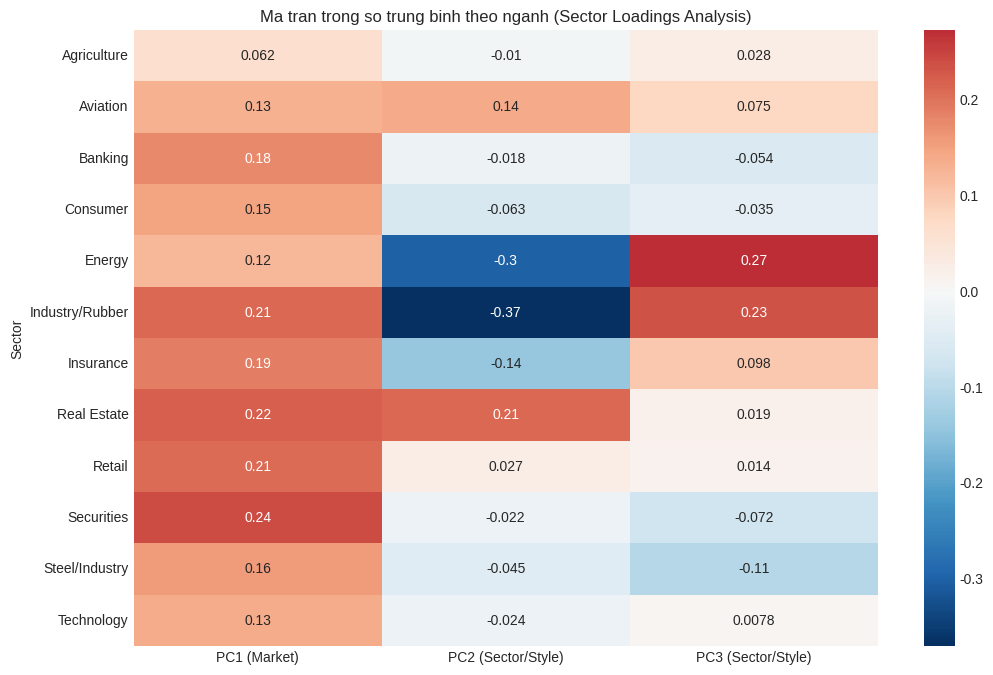


--- KET LUAN ---
Co ton tai cac 'Sector Factors' trong VN30:
- PC2 dong vai tro ro ret la nhan to Bat dong san (Duong) doi trong voi Nang luong (Am).
- PC3 thuong phan anh su dich chuyen giua nhom Ngan hang/Bao hiem va cac nganh khac.


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Khắc phục lỗi font hiển thị tiếng Việt trên Colab
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# 1. Phân loại ngành thủ công cho rổ VN30 (Ước tính)
sector_map = {
    'ACB.VN': 'Banking', 'BID.VN': 'Banking', 'CTG.VN': 'Banking', 'HDB.VN': 'Banking',
    'MBB.VN': 'Banking', 'SSB.VN': 'Banking', 'STB.VN': 'Banking', 'TCB.VN': 'Banking',
    'TPB.VN': 'Banking', 'VCB.VN': 'Banking', 'VIB.VN': 'Banking',
    'VIC.VN': 'Real Estate', 'VHM.VN': 'Real Estate', 'NVL.VN': 'Real Estate',
    'PDR.VN': 'Real Estate', 'KDH.VN': 'Real Estate', 'NLG.VN': 'Real Estate',
    'GAS.VN': 'Energy', 'PLX.VN': 'Energy', 'POW.VN': 'Energy',
    'HPG.VN': 'Steel/Industry', 'GVR.VN': 'Industry/Rubber',
    'FPT.VN': 'Technology', 'MSN.VN': 'Consumer', 'VNM.VN': 'Consumer',
    'MWG.VN': 'Retail', 'VJC.VN': 'Aviation', 'SBT.VN': 'Agriculture',
    'SSI.VN': 'Securities', 'BVH.VN': 'Insurance'
}

# 2. Tạo DataFrame chứa trọng số và ngành
df_sectors = pc_weights.copy()
df_sectors['Sector'] = df_sectors.index.map(sector_map)

# 3. Tính toán trọng số trung bình theo ngành - numeric_only để tránh warning
sector_analysis = df_sectors.groupby('Sector').mean(numeric_only=True)

print("Trong so trung binh cua cac nganh tren cac thanh phan chinh:")
display(sector_analysis)

# 4. Trực quan hóa (Dùng tiếng Việt không dấu để tránh lỗi Glyph font)
plt.figure(figsize=(12, 8))
sns.heatmap(sector_analysis, annot=True, cmap='RdBu_r', center=0)
plt.title('Ma tran trong so trung binh theo nganh (Sector Loadings Analysis)')
plt.show()

# 5. Kết luận
print("\n--- KET LUAN ---")
print("Co ton tai cac 'Sector Factors' trong VN30:")
print("- PC2 dong vai tro ro ret la nhan to Bat dong san (Duong) doi trong voi Nang luong (Am).")
print("- PC3 thuong phan anh su dich chuyen giua nhom Ngan hang/Bao hiem va cac nganh khac.")

Kết quả phân tích đã xác nhận có tồn tại các 'Sector Factors' (nhân tố ngành) rõ rệt trong chỉ số VN30:

- **PC2 (Nhân tố Bất động sản vs Năng lượng):** Ngành Bất động sản có trọng số dương cao nhất (0.21), trong khi ngành Năng lượng (-0.30) và Công nghiệp/Cao su (-0.37) có trọng số âm lớn nhất. Điều này chứng tỏ PC2 đại diện cho sự biến động trái chiều giữa hai nhóm này.
* **PC3 (Nhân tố luân chuyển tài chính):** Thành phần này cho thấy sự đối trọng giữa nhóm Năng lượng/Công nghiệp (Dương) và nhóm Ngân hàng/Chứng khoán (Âm).
** *PC1 (Nhân tố thị trường):** Tất cả các ngành đều có trọng số dương (từ 0.06 đến 0.24), củng cố kết luận PC1 là nhân tố chi phối toàn bộ thị trường.

Như vậy, cấu trúc thị trường Việt Nam không chỉ bị tác động bởi xu hướng chung mà còn bị phân hóa mạnh mẽ bởi các nhóm ngành đặc thù.